# Machine Learning for Financial Inclusion

*Predicting Account Ownership and Designing Evidence-Based Interventions*

---

# (A). BUSINESS UNDERSTANDING 

## 1. ***Understanding the Challenge***

Imagine two individuals:

* **Amina**, a 27-year-old fruit seller in Kisumu. She saves small amounts daily but has no bank account.
* **Joseph**, a boda boda rider in Eldoret. He uses mobile money regularly, yet has never seen the need to open a formal account.

Amina and Joseph represent millions of people across the world. Globally, about **1.4 billion adults** remain outside the formal financial system.

Why does this matter?
Without an account, people:

* Cannot save securely.
* Have limited access to credit for business or emergencies.
* Miss out on insurance, pensions, and government transfers.

Financial exclusion is not just an individual issue. It slows down economic development and limits opportunities for entire communities.

---

## 2. ***The Problem with Current Approaches***

For years, governments and financial institutions have tried to close this gap by:

* Expanding bank branches
* Reducing account fees
* Simplifying account opening procedures

These measures have helped, but they also face **three key limitations**:

1. **Inefficient Targeting** – Programs often reach people who would eventually open accounts on their own, while leaving behind those who truly face barriers.
2. **Intervention Mismatch** – Many strategies assume poverty or distance is the main issue, but evidence suggests that behaviours like saving habits or digital use may be more important.
3. **Uniform Strategies** – One-size-fits-all programs ignore that different groups face different obstacles. A rural farmer and an urban student require very different solutions.

As a result, resources are wasted, and the most excluded populations remain unreached.

---

## 3. ***Our Approach***

This project applies **machine learning** to move from assumption-driven strategies to evidence-based decisions.

We focus on four main components:

* **Prediction**: Build models to estimate an individual’s likelihood of having a financial account.
* **Driver Identification**: Determine which factors (savings, digital use, business activity, demographics) matter most.
* **Segmentation**: Group people into clusters with similar patterns, so interventions can be tailored to specific needs.
* **Actionable Insights**: Translate results into practical strategies for policymakers, financial institutions, and development organisations.

---

## 4. ***The Data***

The analysis uses the **Global Findex 2024 dataset**, covering:

* **8,476 individuals**
* **29 features** across demographics, behaviours, digital adoption, and geographic context

Examples of features:

* **Demographics**: age, gender, income group
* **Financial behaviours**: saving, borrowing, remittances
* **Digital adoption**: mobile money, internet use
* **Contextual factors**: region, rural/urban status

This dataset is large and diverse enough to build reliable predictive models and uncover meaningful patterns.

---




## 5. ***Project Objectives***

### Objective 1: *Predictive Modelling*

Build models that can predict financial account ownership with over **85% accuracy**.

### Objective 2: *Identify Drivers*

Rank the most important factors influencing financial inclusion, such as savings behaviour, mobile money use, or income.

### Objective 3: *Population Segmentation*

Use clustering methods to discover **2–6 meaningful groups** with distinct characteristics.

### Objective 4: *Recommendations*

Provide clear, evidence-based strategies for:

* Policymakers
* Financial institutions
* Development organisations

---

## 6. ***Why This Project is Different***

Most financial inclusion studies stop at describing the excluded.
This project goes further by:

* Moving from **description** to **prediction** and **action**
* Using data to **test assumptions**, not just repeat them
* Designing interventions that are **targeted**, not one-size-fits-all

---

## 7. ***In Simple Terms***

This notebook uses machine learning as a **guide**.
It will help us answer three big questions:

1. **Who** is most likely to be excluded?
2. **Why** are they excluded?
3. **What** can we do about it?

The analysis begins here, but the goal is bigger than accuracy.
It is about making financial inclusion strategies **smarter, fairer, and more impactful**.

---


# (B). DATA UNDERSTANDING

## (a). ***Set your environment.***

This code sets up the environment for **data analysis, preprocessing, and visualization**:

1. **Library Imports**  
   - **Pandas / NumPy:** For handling and manipulating structured data.  
   - **Requests:** To download or retrieve datasets from the web.  
   - **Matplotlib / Seaborn:** For creating clear, visually appealing plots and charts.  
   - **KNNImputer:** To fill missing values by finding similar data points (K-Nearest Neighbors).  
   - **LabelEncoder / StandardScaler:** For encoding categorical variables into numeric form and standardizing numeric features.

2. **Warning Control**  
   Suppresses warning messages to keep the notebook output clean.

3. **Visualization Styling**  
   Applies a consistent and professional plot style (`default` from Matplotlib) and a color palette (`Set2` from Seaborn) for better readability and aesthetics.


In [33]:
import pandas as pd               # Data manipulation and analysis
import numpy as np                # Numerical operations
import requests                    # Fetching data from URLs or APIs
import matplotlib.pyplot as plt    # Data visualization (plots, charts)
import seaborn as sns              # Advanced statistical data visualization
from sklearn.impute import KNNImputer      # Fill missing values using KNN
from sklearn.preprocessing import LabelEncoder, StandardScaler  # Encode categorical vars & standardize features
import warnings                    # Control warning messages
import ipywidgets as widgets
from IPython.display import display


from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVR, SVC
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.metrics import (r2_score, mean_squared_error, mean_absolute_error, 
                           accuracy_score, precision_score, recall_score, f1_score, 
                           roc_auc_score, classification_report, confusion_matrix)
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')


import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Set style for consistent visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


warnings.filterwarnings('ignore')  # Suppress warning messages for cleaner output

# Set clean styling for plots
#plt.style.use('default')           # Use Matplotlib's default style
#sns.set_palette("Set2")            # Set Seaborn's color palette to 'Set2'

from sklearn.feature_selection import SelectKBest, chi2, f_classif,f_regression,mutual_info_regression

from scipy.stats import chi2_contingency

from sklearn.impute import KNNImputer



## (b).  ***Loading the dataset***
- Fetch the datataset
- Note: Ensure you have the correct path to the CSV file

In [34]:
# ===============================================================
#  LOADING THE DATASET + OVERVIEW
# ===============================================================


# Fetch the datataset

globalfin = pd.read_csv("GlobalFindexDatabase2025.csv")

# Display the first few rows of the DataFrame 
# named 'globalfin'
globalfin.head()

,countrynewwb,codewb,year,pop_adult,regionwb24_hi,incomegroupwb24,group,group2,account_t_d,fiaccount_t_d,...,con12m_s,con26lm_s,con12w_s,con2f_s,con13_s,con26m_s,con28lm_s,con5a_s,con17c_s,con32h_s
0,Afghanistan,AFG,2011,14575546.0,South Asia (excluding high income),Low income,all,all,0.090050,0.090050,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Albania,ALB,2011,2281010.0,Europe & Central Asia (excluding high income),Upper middle income,all,all,0.282681,0.282681,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Algeria,DZA,2011,26251587.0,Middle East & North Africa (excluding high inc...,Lower middle income,all,all,0.332861,0.332861,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Angola,AGO,2011,12779501.0,Sub-Saharan Africa (excluding high income),Lower middle income,all,all,0.392035,0.392035,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Argentina,ARG,2011,30685516.0,Latin America & Caribbean (excluding high income),Upper middle income,all,all,0.331302,0.331302,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
## Get an overview of globalfin info, and descriptive statistics
print("shape:", globalfin.shape)
print("duplicates:", globalfin.duplicated().sum())
print("\ncolumns:\n", globalfin.columns.tolist())       
print(globalfin.info())
print(globalfin.describe(include='all'))
print(globalfin.dtypes)


shape: (8566, 437)
duplicates: 0

columns:
 ['countrynewwb', 'codewb', 'year', 'pop_adult', 'regionwb24_hi', 'incomegroupwb24', 'group', 'group2', 'account_t_d', 'fiaccount_t_d', 'mobileaccount_t_d', 'borrow_any_t_d', 'fin4_d', 'dig_acc', 'fin11_2a', 'fin11a', 'fin11b', 'fin11c', 'fin11f', 'fin11d', 'fin11e', 'fin14a', 'fin14b', 'fin14c', 'fin14d', 'fin13_1a', 'fin13_1b', 'fin26a', 'fin26b', 'fin27a', 'fin27b', 'fin17f', 'fin17a_17a1_d', 'fin17a', 'fin17b', 'fin17c', 'fin22d', 'fin22e', 'fin22a_22a1_22g_d', 'fin22a', 'fin22a_1', 'fin22b', 'fin22c', 'fin24sav', 'fin24fam', 'fin24work', 'fin24bor', 'fin24sell', 'fin24other', 'fin24aVD', 'fin24aSD', 'fin24aND', 'fin24aSD_ND', 'fin24aP', 'fin24aN', 'fin24sav_SD_ND', 'fin24fam_SD_ND', 'fin24work_SD_ND', 'fin24bor_SD_ND', 'fin24sell_SD_ND', 'fin24other_SD_ND', 'fin24sav_VD', 'fin24fam_VD', 'fin24work_VD', 'fin24bor_VD', 'fin24sell_VD', 'fin24other_VD', 'fh1', 'fin28', 'fh2', 'fin29', 'fin31a_31b', 'fin30', 'fin31a', 'fin31b', 'fin31d', 'fin3

## (c). ***Global Financial Dataset Overview***

##### **1. Shape — The Size of Our Playground**
* **Rows (8,566)** → each row is one observation (could be a country in a year, or a group within a country).
* **Columns (437)** → each column is a variable (like a question in a survey).

> Big datasets like this can be powerful, but they can also be messy — the first job is to *understand the layout*.

##### **2. Column Information — What's in the Menu?**

Some important columns:

* **Identifiers** (like name tags):

  * `countrynewwb`: Country name
  * `codewb`: Short code (e.g., “KEN” for Kenya)
  * `year`: Year of observation
  * `pop_adult`: Adult population size

* **Descriptors** (categorical info):

  * `regionwb24_hi`: Region grouping (like “East Asia & Pacific”)
  * `incomegroupwb24`: World Bank income classification (High, Upper-Middle, etc.)

* **Financial Indicators**:

  * `account_t_d`: Owns an account (traditional or digital)
  * `fiaccount_t_d`: Owns a financial institution account
  * `mobileaccount_t_d`: Owns a mobile money account
  * `borrow_any_t_d`, `fin24sav`: borrowing/saving activity

* **Survey Codes** (`fin*`, `con*`):
  These are more specialised — they might represent answers to specific survey questions.

##### **3. Data Types — What Kind of Stuff Is This?**

From `.dtypes` we see:

* **Float64 (430 columns)** → decimal numbers, percentages, proportions, scores
* **Int64 (1 column)** → integers (whole numbers) — here it’s `year`
* **Object (6 columns)** → text or mixed content (country names, codes, categories)

>  Knowing data types is important because it affects what operations we can do — you can’t average a text column, but you can group by it.

---

##### **5. Descriptive Statistics**

From `.describe(include='all')` we learn:

**Time Range:**

* Earliest year: 2011
* Latest year: 2024

**Countries:**

* 174 unique countries
* Most frequent: *Mexico* (57 observations)

**Population (`pop_adult`):**

* Smallest: \~228,000 adults
* Largest: \~1.17 billion adults (India or China likely)
* Average: \~37.99 million

**Account Ownership (`account_t_d`):**

* Mean: 0.61 → On average, 61% of adults in the dataset have an account.
* Min: 0.004 → Some countries have near-zero coverage.
* Max: 1.0 → Full coverage (100% account ownership).
---

##### **6. Special Notes**

* Many columns end in `_s` → these may be *standardised*, *scaled*, or *summary* variables from raw responses.
* Some survey columns have only **1 or 2 non-null values** → these might be pilot questions, rare cases, or data errors.

##### **7. There are NO duplicates**

## (d). ***Checking on Missing values.***
- Explore the 

-       data types 
-       missing values
-       unique counts

In [36]:
# Create a summary DataFrame to show data types, missing values, and unique counts
# summary: dtype / missing / unique
summary = pd.DataFrame({
    'dtype': globalfin.dtypes.astype(str),
    'n_missing': globalfin.isnull().sum(),
    'pct_missing': globalfin.isnull().mean(),
    'n_unique': globalfin.nunique(dropna=False)
})
summary = summary.sort_values('pct_missing', ascending=False)
summary.head(20)   # show top 20 by missingness

,dtype,n_missing,pct_missing,n_unique
con32h_s,float64,8565,0.999883,2
con17c_s,float64,8565,0.999883,2
con5a_s,float64,8565,0.999883,2
fin32_33_34b_s,float64,8565,0.999883,2
con13_s,float64,8565,0.999883,2
con26m_s,float64,8565,0.999883,2
con12m_s,float64,8565,0.999883,2
con28lm_s,float64,8565,0.999883,2
fin37_38_39d_s,float64,8565,0.999883,2
fing2p_card_s,float64,8565,0.999883,2


### ***Conclusion on the missing values.***
**Observation:**

- Many columns have over 99% missing values.

- These columns might only apply to a tiny subset of the dataset.

- Some have very few unique values (e.g., 2–4), which might limit their usefulness.


**Takeaways:**

- The dataset is very wide → not all columns will be equally useful.

- A large portion of the data is missing for many variables.

Before modeling, you’ll likely need:

- **Feature selection** → drop or combine high-missingness columns.

- **Imputation** → fill missing values if they’re still important.

- **Understanding the _s columns** → check documentation to know if they’re relevant to your analysis.

# (C). ***DATA CLEANING***

## (a). ***Create Working Copy***
   - Preserve Original Data Integrity 
   - Create a working copy for exploration and transformation without altering the raw dataset.
      

In [37]:
#Create Working Copy and Basic Cleaning
# Create working copy
df = globalfin.copy()

print(f"Starting with: {df.shape}")
print(f"Target variable 'account_t_d' missing: {df['account_t_d'].isnull().sum()} ({df['account_t_d'].isnull().mean():.1%})")

Starting with: (8566, 437)
Target variable 'account_t_d' missing: 90 (1.1%)


## (b). ***Remove Metadata/Identifier Columns***

   - Eliminate Non-Predictive Metadata
   - Remove identifiers and contextual columns (e.g., country names, codes, year) that do not directly influence predictions and may cause information leakage.


In [38]:
# Columns to remove (metadata that shouldn't be used for prediction)
metadata_cols = [
    'countrynewwb',  # Country name (text)
    'codewb',        # Country code  
    'year',          # Year (could cause data leakage)
    'pop_adult'      # Population size (not individual-level)
]

# Check if these columns exist before dropping
existing_metadata = [col for col in metadata_cols if col in df.columns]
df_clean = df.drop(columns=existing_metadata)

print(f"Removed {len(existing_metadata)} metadata columns")
print(f"New shape: {df_clean.shape}")


Removed 4 metadata columns
New shape: (8566, 433)


## (c). ***Target Variable Analysis***

   - Examine Target Distribution
   - Confirm the format, range, and structure of `account_t_d` to ensure it is correctly defined for modeling.

In [39]:
# Analyze our target variable
target_stats = df_clean['account_t_d'].describe()
print("Target Variable (account_t_d) Statistics:")
print(target_stats)

# Check for valid range (should be 0-1 for proportions)
print(f"\nRange: {df_clean['account_t_d'].min():.4f} to {df_clean['account_t_d'].max():.4f}")


Target Variable (account_t_d) Statistics:
count    8476.000000
mean        0.609056
std         0.281218
min         0.004049
25%         0.374352
50%         0.619868
75%         0.875940
max         1.000000
Name: account_t_d, dtype: float64

Range: 0.0040 to 1.0000


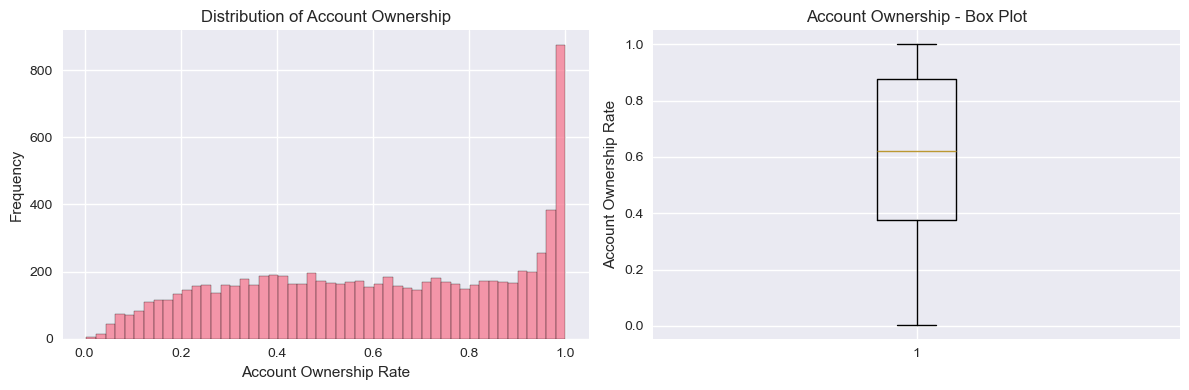

In [40]:
## Visualize the distribution of the target variable
## - Histogram
## - Box plot
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(df_clean['account_t_d'].dropna(), bins=50, alpha=0.7, edgecolor='black')
plt.title('Distribution of Account Ownership')
plt.xlabel('Account Ownership Rate')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.boxplot(df_clean['account_t_d'].dropna())
plt.title('Account Ownership - Box Plot')
plt.ylabel('Account Ownership Rate')

plt.tight_layout()
plt.show()

In [41]:
# Check if we have individual-level or aggregated data
print("Unique values in account_t_d (first 20):")
print(df_clean['account_t_d'].value_counts().head(20))

# Check if we have group-level data
if 'group' in df_clean.columns:
    print(f"\nGroup types: {df_clean['group'].value_counts()}")
if 'group2' in df_clean.columns:
    print(f"\nGroup2 types: {df_clean['group2'].value_counts()}")

Unique values in account_t_d (first 20):
account_t_d
1.000000    186
0.979718      2
0.651160      2
0.823221      2
0.685647      1
0.570173      1
0.871107      1
0.775988      1
0.963450      1
0.827969      1
0.634705      1
0.376106      1
0.755855      1
0.660206      1
0.879884      1
0.787895      1
0.302600      1
0.558604      1
0.528249      1
0.133531      1
Name: count, dtype: int64

Group types: group
gender        1508
age_cat       1508
education     1506
laborforce    1488
income        1482
all            771
urbanicity     303
Name: count, dtype: int64

Group2 types: group2
all                      771
men                      754
women                    754
ages 15-24               754
age 25+                  754
secondary edu or more    753
prim edu or less         753
in laborforce            744
out of laborforce        744
poorest 40%              741
richest 60%              741
urban                    152
rural                    151
Name: count, dtype: int

### ***Target Analysis Observations***

***Target Distribution Insights***

- Bimodal distribution: Heavy concentration at 1.0 (perfect inclusion) and spread across 0.4-0.8 range
- 186 observations with 100% account ownership - likely developed countries/high-income groups
- Median at 62% - shows global financial inclusion is still a work in progress
- Data is GROUP-LEVEL aggregated - not individual responses but demographic segments

***Data Structure Revelation***

- Group types: gender, age_cat, education, laborforce, income, urbanicity
- Group2 breakdown: men/women, age ranges, education levels, income quintiles
- This is **DEMOGRAPHIC SEGMENT** data - each row represents account ownership rate for a specific population group


## (d) ***Drop highly Missing Values >65% missing*** 
   - Quantify and categorize missingness, and drop features with excessive data gaps to maintain analytical reliability.
   - Group the data by how much is missing to help in decision making.
   - Remove ***393 high-missingness columns** (>65% missing) - likely country-specific questions
   - Massive dimensionality reduction: **433 → 40** features 


In [42]:
# Create detailed missingness report
def analyze_missingness(df):
    missing_info = pd.DataFrame({
        'column': df.columns,
        'missing_count': df.isnull().sum(),
        'missing_pct': df.isnull().mean() * 100,
        'dtype': df.dtypes.astype(str),
        'unique_values': df.nunique()
    }).sort_values('missing_pct', ascending=False)
    
    return missing_info

missing_report = analyze_missingness(df_clean)
print("Top columns by missingness:")
print(missing_report.head(5))

Top columns by missingness:
                        column  missing_count  missing_pct    dtype  \
con26m_s              con26m_s           8565    99.988326  float64   
con28lm_s            con28lm_s           8565    99.988326  float64   
con5a_s                con5a_s           8565    99.988326  float64   
con17c_s              con17c_s           8565    99.988326  float64   
fin37_38_39d_s  fin37_38_39d_s           8565    99.988326  float64   

                unique_values  
con26m_s                    1  
con28lm_s                   1  
con5a_s                     1  
con17c_s                    1  
fin37_38_39d_s              1  


In [43]:
# Categorize columns by missingness level
high_missing = missing_report[missing_report['missing_pct'] > 65]['column'].tolist()
med_missing = missing_report[(missing_report['missing_pct'] > 45) & (missing_report['missing_pct'] <= 65)]['column'].tolist()
low_missing = missing_report[missing_report['missing_pct'] <= 45]['column'].tolist()

print(f"High missingness (>65%): {len(high_missing)} columns")
print(f"Medium missingness (45-65%): {len(med_missing)} columns") 
print(f"Low missingness (<45%): {len(low_missing)} columns")

# Remove high missingness columns (>90% missing)
print(f"\nRemoving {len(high_missing)} high-missingness columns")
df_clean = df_clean.drop(columns=high_missing)
print(f"New shape: {df_clean.shape}")

High missingness (>65%): 393 columns
Medium missingness (45-65%): 18 columns
Low missingness (<45%): 22 columns

Removing 393 high-missingness columns
New shape: (8566, 40)


## (e). Numerical features variance analysis.
   - Checking which numerical columns in the dataset don’t change much (i.e., almost all the values are the same).
   - If a feature has very **low variance**, it means it gives almost no new information because it doesn’t really distinguish one data point from another.
   - Low variance analysis helps you spot and remove features with little to no variability, so that the model focuses only on meaningful information.
   - Remove **6 low variance columns** (<0.02 variance ) 
   - Significant dimensionality reduction: **40 → 34** features 

   

In [44]:
# Check variance for numerical columns
numerical_cols = df_clean.select_dtypes(include=[np.number]).columns
variance_info = pd.DataFrame({
    'column': numerical_cols,
    'variance': df_clean[numerical_cols].var(),
    'std': df_clean[numerical_cols].std(),
    'unique_values': df_clean[numerical_cols].nunique()
}).sort_values('variance')

print("Lowest variance numerical features:")
print(variance_info.head(10))

Lowest variance numerical features:
                        column  variance       std  unique_values
fin22d                  fin22d  0.008397  0.091638           4026
fin24aSD              fin24aSD  0.008465  0.092004           3035
fin22b                  fin22b  0.015390  0.124055           6032
fin42                    fin42  0.017318  0.131599           3411
fin37                    fin37  0.017858  0.133633           3862
fin32_n33            fin32_n33  0.019389  0.139243           5778
borrow_any_t_d  borrow_any_t_d  0.021793  0.147625           6400
fin32_n33_acc    fin32_n33_acc  0.022780  0.150931           3531
fin32_n33_34a    fin32_n33_34a  0.023872  0.154506           3108
fing2p_fin          fing2p_fin  0.025068  0.158330           3615


In [45]:
# Remove near-zero variance features (e.g., <0.001 variance)
low_var_threshold = 0.02
low_var_cols = variance_info[variance_info['variance'] < low_var_threshold]['column'].tolist()

if low_var_cols:
    print(f"\nRemoving {len(low_var_cols)} low-variance columns")
    df_clean = df_clean.drop(columns=low_var_cols)
    print(f"New shape: {df_clean.shape}")


Removing 6 low-variance columns
New shape: (8566, 34)


## (e). ***Correlation Analysis***
  
   - Correlation analysis with the target variable measures how strongly each feature relates to the outcome.
   - Features with higher correlation often have stronger predictive power.  
   - Extremely high correlation (≥0.9) may indicate data leakage rather than true prediction. 
   - The goal is to keep genuine predictors while dropping redundant or leaking features.
   - Remove **5 highly correlated columns** (>89% correlation ) 
   - Significant dimensionality reduction: **34 → 29** features 
 



In [46]:
#Identify Potential Leakage Variables
# Look for variables that might leak information about the target
# These often have names suggesting they measure financial behavior
potential_leakage = []

for col in df_clean.columns:
    if col != 'account_t_d':
        # Check correlation with target (high correlation might indicate leakage)
        if df_clean[col].dtype in ['float64', 'int64']:
            corr = df_clean[col].corr(df_clean['account_t_d'])
            if abs(corr) > 0.7:  # Very high correlation
                potential_leakage.append((col, corr))

print("Potential data leakage candidates (high correlation with target):")
for col, corr in sorted(potential_leakage, key=lambda x: abs(x[1]), reverse=True)[:10]:
    print(f"{col}: correlation = {corr:.4f}")



Potential data leakage candidates (high correlation with target):
fiaccount_t_d: correlation = 0.9591
g20_any: correlation = 0.9551
g20_made: correlation = 0.8951
fin2_t_d: correlation = 0.8950
g20_received: correlation = 0.8936
fin31a_31b: correlation = 0.7796
fin26a: correlation = 0.7671
fin31a: correlation = 0.7656
fin17a: correlation = 0.7600
fin17a_17a1_d: correlation = 0.7564


In [47]:
#drop columns with high correlation with target if corr >  0.8
for col, corr in potential_leakage:
    if abs(corr) > 0.8:
        df_clean.drop(columns=[col], inplace=True)

print(f"\nRemoved {len([1 for col, corr in potential_leakage if abs(corr) > 0.8])} potential leakage columns")
print(f"New shape: {df_clean.shape}")


Removed 5 potential leakage columns
New shape: (8566, 29)


## (f). ***Column Renaming.***

   - The columns in the dataset are being renamed to make them more **readable, consistent, and meaningful**.
   - Original technical names (e.g., `regionwb24_hi`, `fin17a`, `fing2p`) are being mapped to simpler names (e.g., `region`, `biz_loan`, `prefer_digital`).
   - This is improving **clarity**, making it easier to interpret variables during analysis. 
   - The renaming is being performed using a dictionary (`rename_map`) and applied with `df.rename(columns=rename_map)`. 
   - The final result is a clean dataframe (`df_clean`) with descriptive column names for analysis and reporting.

In [48]:
df_clean.columns

Index(['regionwb24_hi', 'incomegroupwb24', 'group', 'group2', 'account_t_d',
       'borrow_any_t_d', 'fin26a', 'fin17a_17a1_d', 'fin17a',
       'fin22a_22a1_22g_d', 'fin22a', 'fin24aSD_ND', 'fin24aP', 'fin24aN',
       'fin31a_31b', 'fin30', 'fin31a', 'fin31d', 'fin32_n33_34a',
       'fin32_n33_acc', 'fin32', 'fin32_acc', 'fin34a', 'fin37_38', 'fin10',
       'fing2p_acc', 'fing2p_fin', 'fing2p', 'save_any_t_d'],
      dtype='object')

In [49]:
rename_map = {
    'regionwb24_hi': 'region',
    'incomegroupwb24': 'income_group',
    'group': 'demo_group',
    'group2': 'demo_subgroup',
    'account_t_d': 'has_account',
    'borrow_any_t_d': 'borrowed_any',
    'fin26a': 'credit_card',
    'fin17a_17a1_d': 'biz_loan_source',
    'fin17a': 'biz_loan',
    'fin22a_22a1_22g_d': 'loan_purpose_group',
    'fin22a': 'loan_purpose',
    'fin24aSD_ND': 'saved_old_age',
    'fin24aP': 'saved_for_purchase',
    'fin24aN': 'saved_no_purpose',
    'fin31a_31b': 'mobile_pay_s_r',
    'fin30': 'digital_payment_other',
    'fin31a': 'mobile_payment',
    'fin31d': 'mobile_payment_bill',
    'fin32_n33_34a': 'govt_digital_pay',
    'fin32_n33_acc': 'govt_digital_pay_acc',
    'fin32': 'digital_pay',
    'fin32_acc': 'digital_pay_acc',
    'fin34a': 'govt_payment_recv',
    'fin37_38': 'fin_resilience',
    'fin10': 'emergency_funds',
    'fing2p_acc': 'prefer_digital_acc',
    'fing2p_fin': 'prefer_digital_fin',
    'fing2p': 'prefer_digital',
    'save_any_t_d': 'saved_any'}
df_clean = df_clean.rename(columns=rename_map)    

In [50]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8566 entries, 0 to 8565
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   region                 7882 non-null   object 
 1   income_group           7882 non-null   object 
 2   demo_group             8566 non-null   object 
 3   demo_subgroup          8566 non-null   object 
 4   has_account            8476 non-null   float64
 5   borrowed_any           6401 non-null   float64
 6   credit_card            3169 non-null   float64
 7   biz_loan_source        6191 non-null   float64
 8   biz_loan               5711 non-null   float64
 9   loan_purpose_group     4955 non-null   float64
 10  loan_purpose           4602 non-null   float64
 11  saved_old_age          3036 non-null   float64
 12  saved_for_purchase     6444 non-null   float64
 13  saved_no_purpose       5080 non-null   float64
 14  mobile_pay_s_r         3939 non-null   float64
 15  digi

# ***FIRST EDA***
- This is to allow us to understand our data before we clean it further.
- What is the data telling us?
- Do a thorough work on the first 29 columns before we do further manipulation. 
- On the stand of financial in inclusivity, what does the data say on the same?

In [51]:
# ==================================================================================
# PART 1: DESCRIPTIVE ANALYTICS (WHAT HAPPENED?)
# Looking at the data as it is - before any processing
# ==================================================================================

print("\nPART 1: DESCRIPTIVE ANALYTICS - WHAT HAPPENED?")
print("-" * 50)

# Visualization 1: Basic Dataset Information
def viz_1_basic_info(df):
    """Simple overview of our dataset"""
    print("VISUALIZATION 1: Dataset Overview")
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Basic stats
    total_rows = df.shape[0]
    total_cols = df.shape[1]
    missing_cells = df.isnull().sum().sum()
    
    # Plot 1: Dataset size
    categories = ['Rows', 'Columns', 'Missing\nCells']
    values = [total_rows, total_cols, missing_cells]
    
    bars = axes[0].bar(categories, values, color=['skyblue', 'lightcoral', 'orange'])
    axes[0].set_title('Dataset Basic Stats')
    axes[0].set_ylabel('Count')
    
    # Add numbers on bars
    for bar, value in zip(bars, values):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values)*0.02,
                    str(value), ha='center', va='bottom', fontweight='bold')
    
    # Plot 2: Data types
    dtype_counts = df.dtypes.value_counts()
    axes[1].pie(dtype_counts.values, labels=dtype_counts.index, autopct='%1.1f%%')
    axes[1].set_title('Data Types Distribution')
    
    # Plot 3: Target variable summary
    target_stats = df['has_account'].describe()
    axes[2].text(0.1, 0.8, 'Target Variable: has_account', fontsize=14, fontweight='bold')
    axes[2].text(0.1, 0.6, f'Average: {target_stats["mean"]:.1%}', fontsize=12)
    axes[2].text(0.1, 0.4, f'Range: {target_stats["min"]:.3f} to {target_stats["max"]:.3f}', fontsize=12)
    axes[2].text(0.1, 0.2, f'Sample Size: {target_stats["count"]:.0f}', fontsize=12)
    axes[2].axis('off')
    axes[2].set_title('Target Variable Summary')
    
    plt.tight_layout()
    plt.show()



PART 1: DESCRIPTIVE ANALYTICS - WHAT HAPPENED?
--------------------------------------------------


VISUALIZATION 1: Dataset Overview


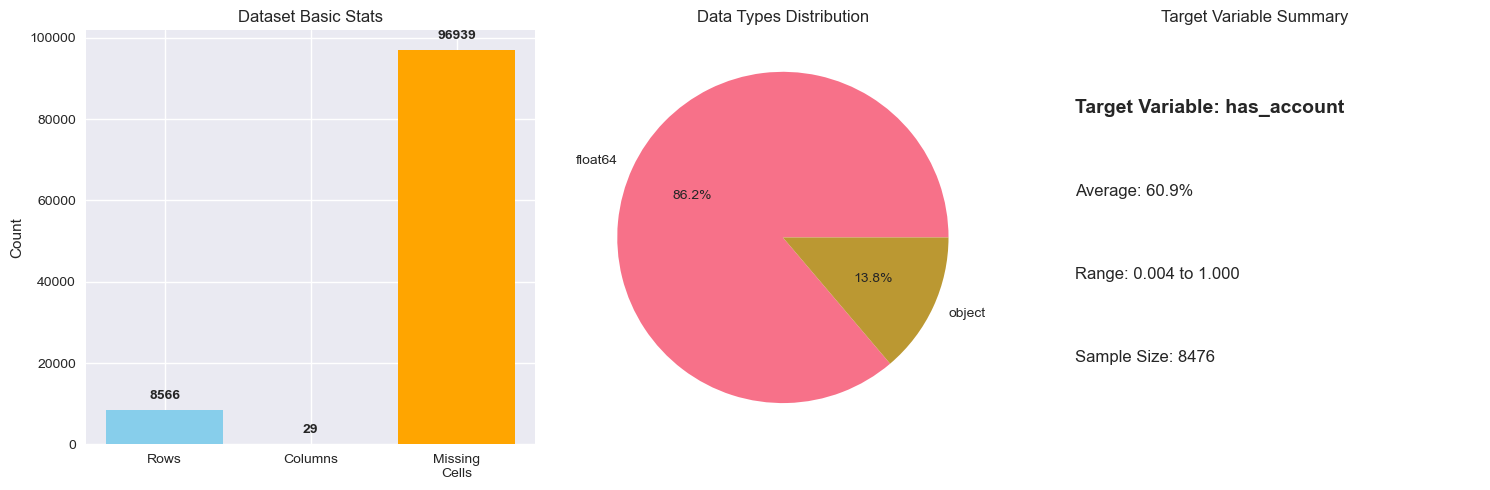

In [52]:
# step 1: Basic dataset info
viz_1_basic_info(df_clean)

In [53]:
def viz_1_basic_info(df):
    """Quick overview of dataset"""
    print("VISUALIZATION 1: Dataset Overview")
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Plot 1: Basic stats
    stats = {
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Missing": df.isnull().sum().sum()
    }
    axes[0].bar(stats.keys(), stats.values(), color=['skyblue','lightcoral','orange'])
    axes[0].set_title("Dataset Stats")

    # Plot 2: Data types
    df.dtypes.value_counts().plot.pie(
        autopct="%1.1f%%", ax=axes[1], legend=False, ylabel=""
    )
    axes[1].set_title("Data Types")

    # Plot 3: Target summary
    target = df["has_account"].describe()
    txt = f"""Target: has_account
Mean: {target['mean']:.1%}
Range: {target['min']:.0f}–{target['max']:.0f}
N: {int(target['count'])}"""
    axes[2].text(0.05, 0.6, txt, fontsize=12)
    axes[2].axis("off")
    axes[2].set_title("Target Summary")

    plt.tight_layout()
    plt.show()


VISUALIZATION 1: Dataset Overview


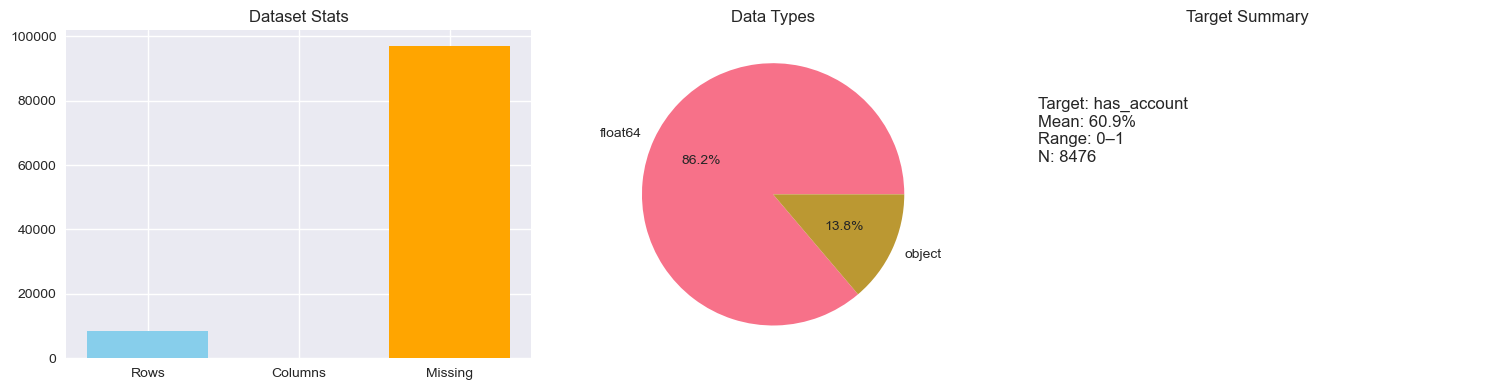

In [54]:
# VIZ 1: Basic dataset info
viz_1_basic_info(df_clean)

In [55]:
def viz_2_missing_data(df):
    """Missing data analysis: per-column + completeness"""
    print("\nVISUALIZATION 2: Missing Data Analysis")
    
    # Missing percentage per column
    missing = df.isnull().mean().sort_values(ascending=False) * 100
    missing = missing[missing > 0]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Missing % by column
    if not missing.empty:
        sns.barplot(x=missing.values, y=missing.index, ax=axes[0], palette="Reds_r")
        axes[0].set_title("Missing Data by Column")
        axes[0].set_xlabel("% Missing")
    else:
        axes[0].text(0.5, 0.5, "No Missing Data!", ha="center", va="center", fontsize=14)
        axes[0].axis("off")

    # Plot 2: Complete vs incomplete records
    complete = df.dropna().shape[0]
    incomplete = df.shape[0] - complete
    sns.barplot(
        x=[complete, incomplete],
        y=["Complete", "Incomplete"],
        ax=axes[1],
        palette=["lightgreen", "salmon"]
    )
    axes[1].set_title("Record Completeness")
    axes[1].set_xlabel("Count")

    plt.tight_layout()
    plt.show()

    return missing



VISUALIZATION 2: Missing Data Analysis


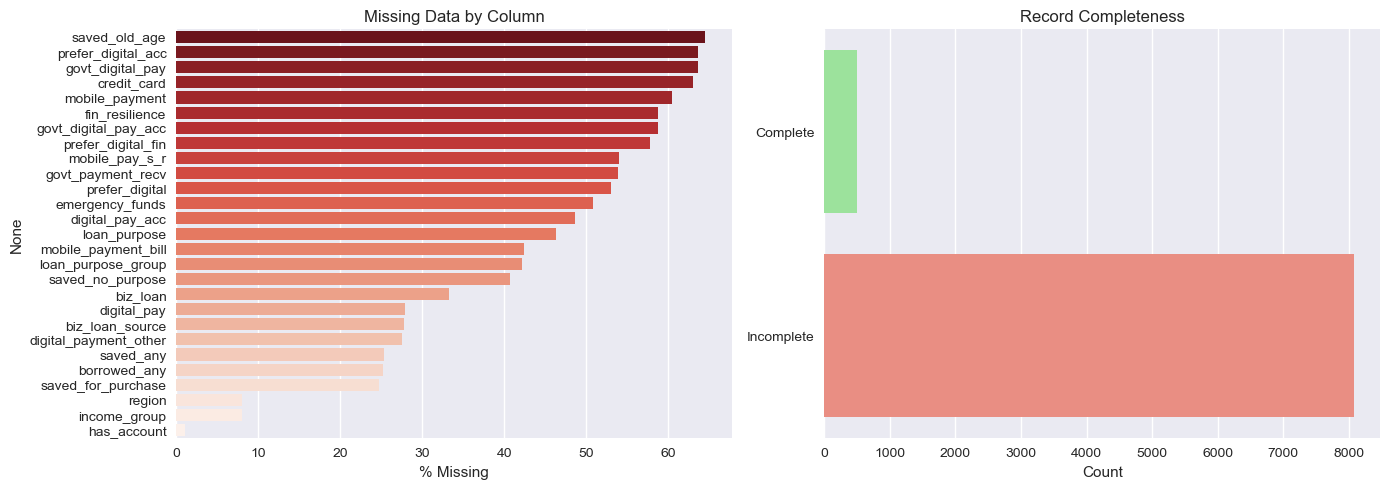

In [56]:
# Viz 2: Missing data analysis
missing_report = viz_2_missing_data(df_clean)

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

def viz_3_target_analysis(df):
    """Deep dive into account ownership"""
    print("\nVISUALIZATION 3: Account Ownership Analysis")

    account = df["has_account"].dropna()
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Plot 1: Distribution
    sns.histplot(account, bins=30, kde=True, ax=axes[0], color="steelblue")
    axes[0].axvline(account.mean(), color="red", ls="--", label=f"Mean: {account.mean():.1%}")
    axes[0].set_title("Distribution of Account Ownership")
    axes[0].legend()

    # Plot 2: By income group
    if "income_group" in df.columns:
        grp = df.groupby("income_group")["has_account"].mean().sort_values()
        sns.barplot(x=grp.index, y=grp.values * 100, ax=axes[1], palette="Greens")
        axes[1].set_title("Ownership by Income Group")
        axes[1].set_ylabel("% Ownership")
        axes[1].tick_params(axis="x", rotation=45)
    else:
        axes[1].text(0.5, 0.5, "No income group data", ha="center", va="center")
        axes[1].axis("off")

    # Plot 3: Stats summary
    txt = f"""Account Ownership Stats
Mean: {account.mean():.1%}
Median: {account.median():.1%}
Min–Max: {account.min():.0%}–{account.max():.0%}
Std Dev: {account.std():.2f}
N: {len(account):,}"""
    axes[2].text(0.05, 0.5, txt, va="center", family="monospace")
    axes[2].axis("off")
    axes[2].set_title("Summary")

    plt.tight_layout()
    plt.show()



VISUALIZATION 3: Account Ownership Analysis


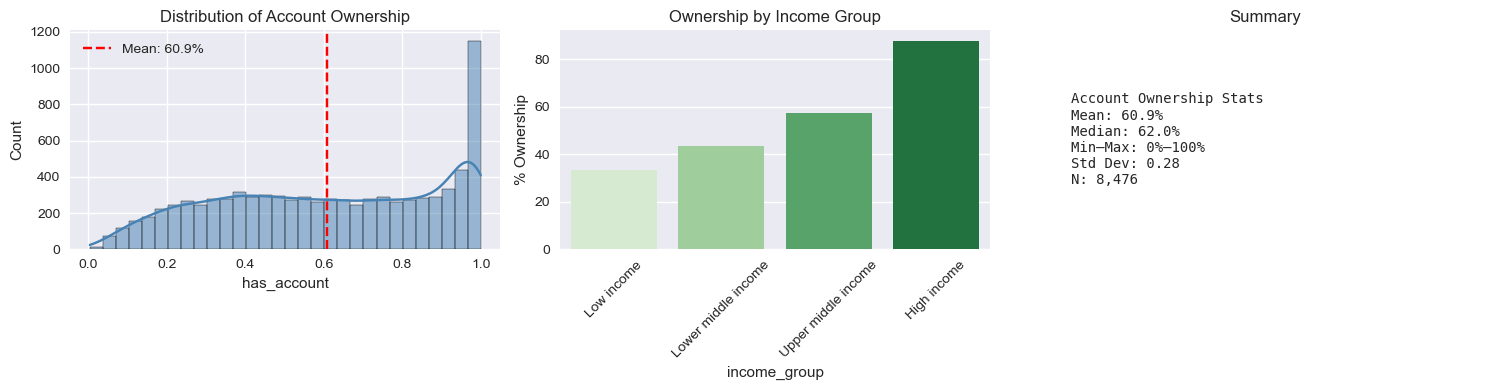

In [58]:
# Step 3: Target variable deep dive
viz_3_target_analysis(df_clean)

In [59]:
# ==================================================================================
# PART 2: DIAGNOSTIC ANALYTICS (WHY DID IT HAPPEN?)
# Finding relationships and understanding causes
# ==================================================================================

print("\n\nPART 2: DIAGNOSTIC ANALYTICS - WHY DID IT HAPPEN?")
print("-" * 50)




PART 2: DIAGNOSTIC ANALYTICS - WHY DID IT HAPPEN?
--------------------------------------------------


In [60]:
# Re-add the metadata columns from the original df
df_temp = df_clean.copy()
for col in metadata_cols:
    if col in df.columns:
        df_temp[col] = df[col]


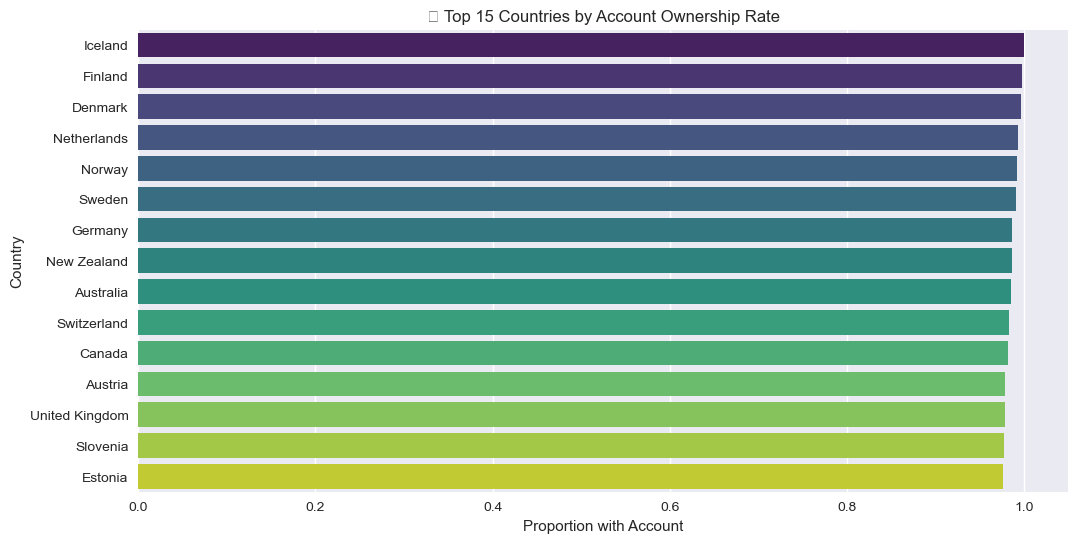

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
country_acc = (
    df_temp.groupby("countrynewwb")["has_account"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

sns.barplot(x=country_acc.values, y=country_acc.index, palette="viridis")
plt.title("📊 Top 15 Countries by Account Ownership Rate")
plt.xlabel("Proportion with Account")
plt.ylabel("Country")
plt.show()


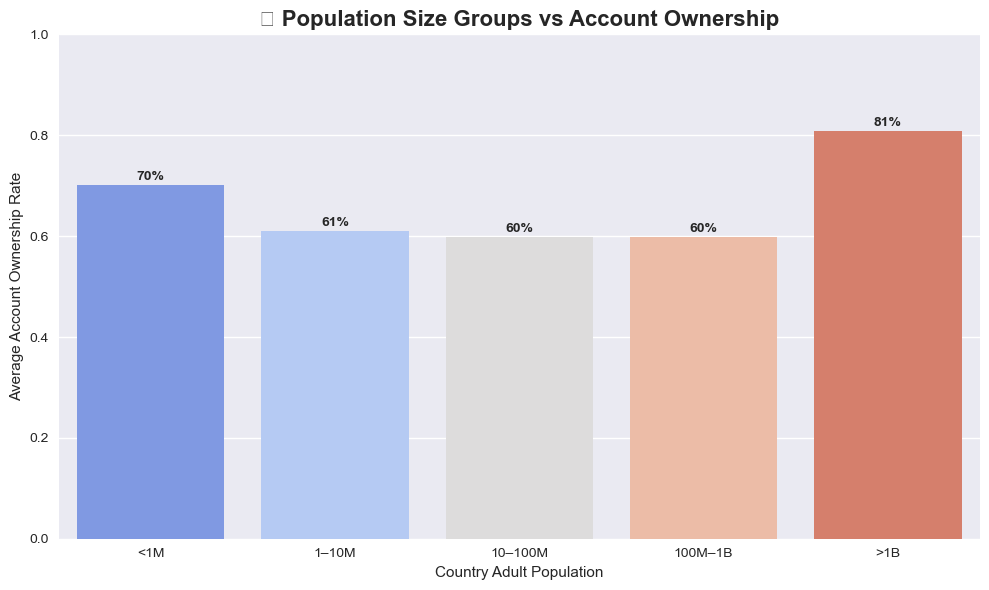

In [62]:
bins = [1e5, 1e6, 1e7, 1e8, 1e9, df_temp["pop_adult"].max()]
labels = ["<1M", "1–10M", "10–100M", "100M–1B", ">1B"]

df_temp["pop_bin"] = pd.cut(df_temp["pop_adult"], bins=bins, labels=labels)

bin_stats = df_temp.groupby("pop_bin")["has_account"].mean().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(
    data=bin_stats,
    x="pop_bin",
    y="has_account",
    palette="coolwarm"
)

for i, row in bin_stats.iterrows():
    plt.text(i, row["has_account"]+0.01, f"{row['has_account']:.0%}",
             ha="center", fontsize=10, weight="bold")

plt.title("👥 Population Size Groups vs Account Ownership", fontsize=16, weight="bold")
plt.xlabel("Country Adult Population")
plt.ylabel("Average Account Ownership Rate")
plt.ylim(0,1)
sns.despine()
plt.tight_layout()
plt.show()


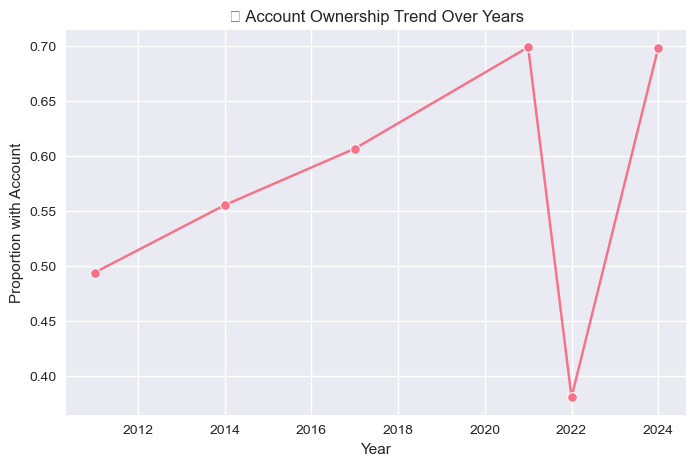

In [63]:
plt.figure(figsize=(8,5))
sns.lineplot(data=df_temp, x="year", y="has_account", estimator="mean", ci=None, marker="o")
plt.title("⏳ Account Ownership Trend Over Years")
plt.ylabel("Proportion with Account")
plt.xlabel("Year")
plt.show()


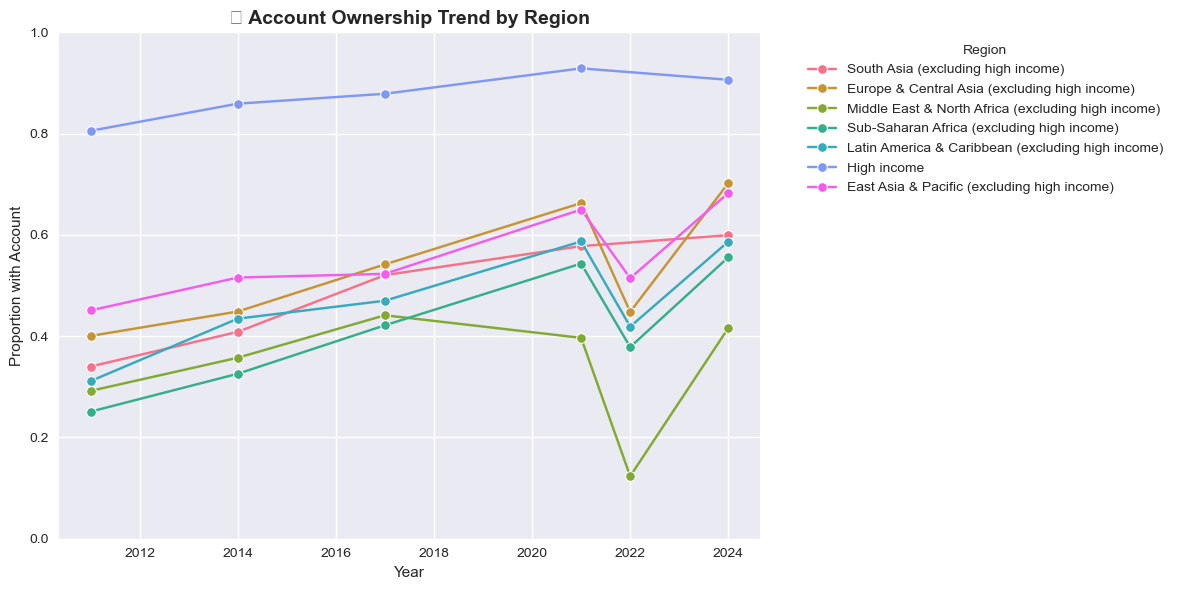

In [64]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=df_temp,
    x="year", y="has_account",
    hue="region", estimator="mean", ci=None,
    marker="o"
)
plt.title("⏳ Account Ownership Trend by Region", fontsize=14, weight="bold")
plt.ylabel("Proportion with Account")
plt.xlabel("Year")
plt.legend(title="Region", bbox_to_anchor=(1.05,1), loc="upper left")
plt.ylim(0, 1)
sns.despine()
plt.tight_layout()
plt.show()


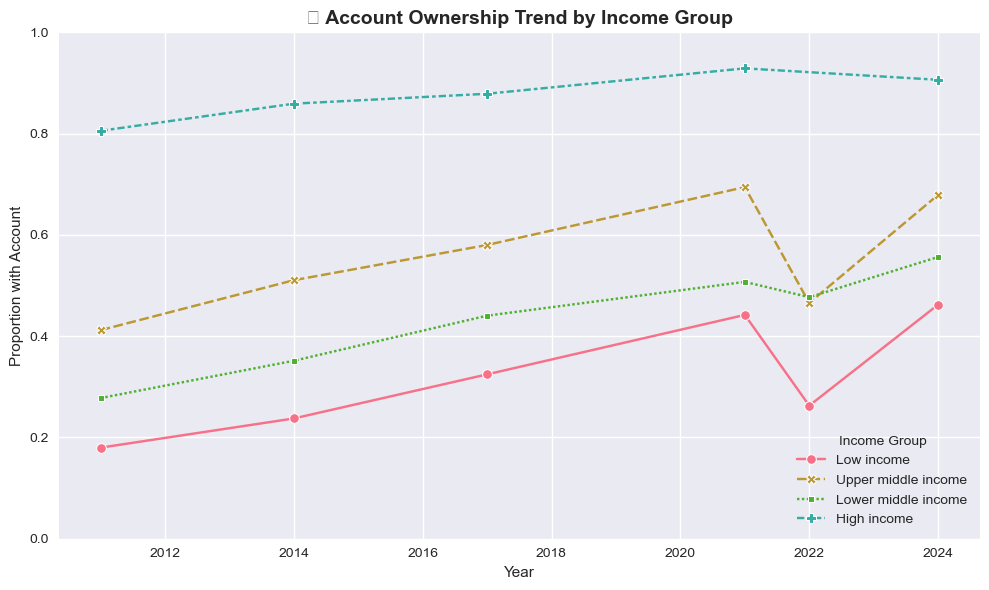

In [65]:
plt.figure(figsize=(10,6))
sns.lineplot(
    data=df_temp,
    x="year", y="has_account",
    hue="income_group", estimator="mean", ci=None,
    style="income_group", markers=True
)
plt.title("⏳ Account Ownership Trend by Income Group", fontsize=14, weight="bold")
plt.ylabel("Proportion with Account")
plt.xlabel("Year")
plt.legend(title="Income Group")
plt.ylim(0, 1)
sns.despine()
plt.tight_layout()
plt.show()


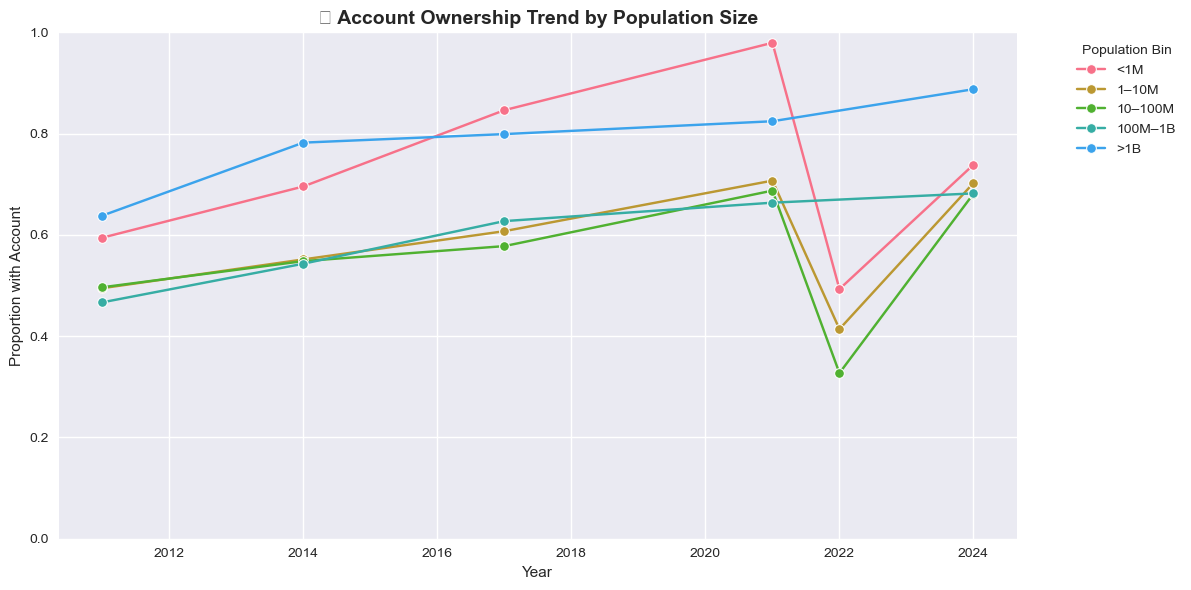

In [66]:
# Bin adult population into categories
bins = [1e5, 1e6, 1e7, 1e8, 1e9, df_temp["pop_adult"].max()]
labels = ["<1M", "1–10M", "10–100M", "100M–1B", ">1B"]
df_temp["pop_bin"] = pd.cut(df_temp["pop_adult"], bins=bins, labels=labels)

plt.figure(figsize=(12,6))
sns.lineplot(
    data=df_temp,
    x="year", y="has_account",
    hue="pop_bin", estimator="mean", ci=None,
    marker="o"
)
plt.title("⏳ Account Ownership Trend by Population Size", fontsize=14, weight="bold")
plt.ylabel("Proportion with Account")
plt.xlabel("Year")
plt.legend(title="Population Bin", bbox_to_anchor=(1.05,1), loc="upper left")
plt.ylim(0, 1)
sns.despine()
plt.tight_layout()
plt.show()


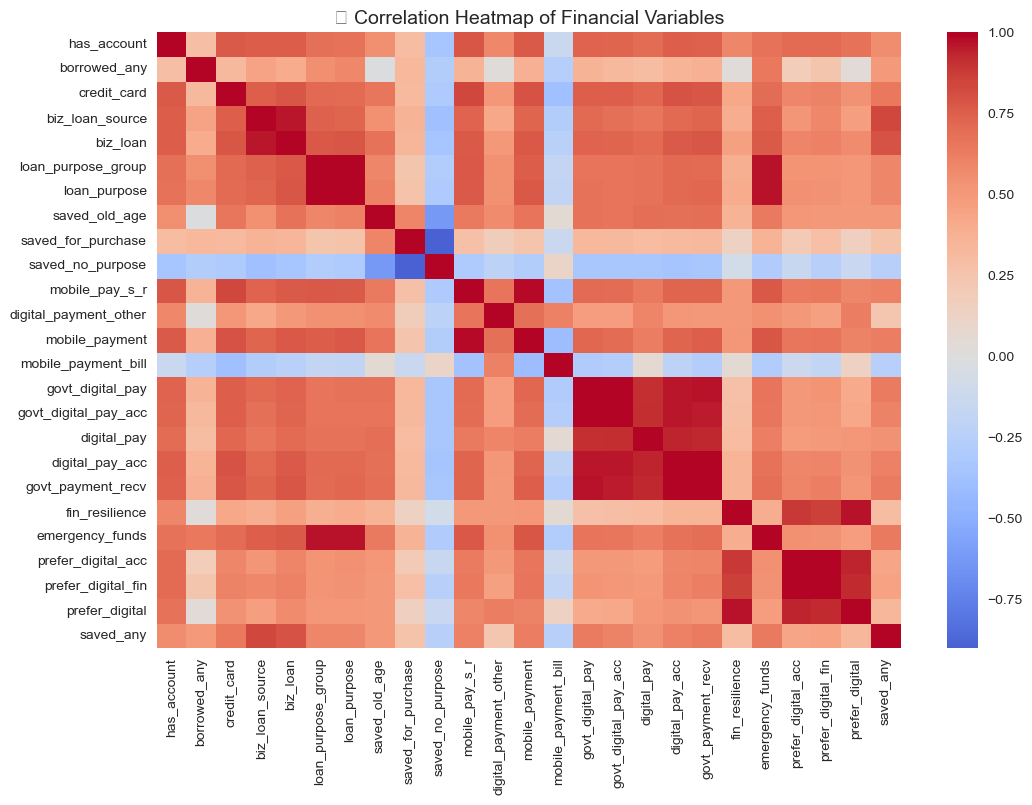

In [67]:
# =========================
# A. CORRELATION & RELATIONSHIPS
# =========================
plt.figure(figsize=(12, 8))
sns.heatmap(df_clean.corr(numeric_only=True), annot=False, cmap="coolwarm", center=0)
plt.title("🔗 Correlation Heatmap of Financial Variables", fontsize=14)
plt.show()



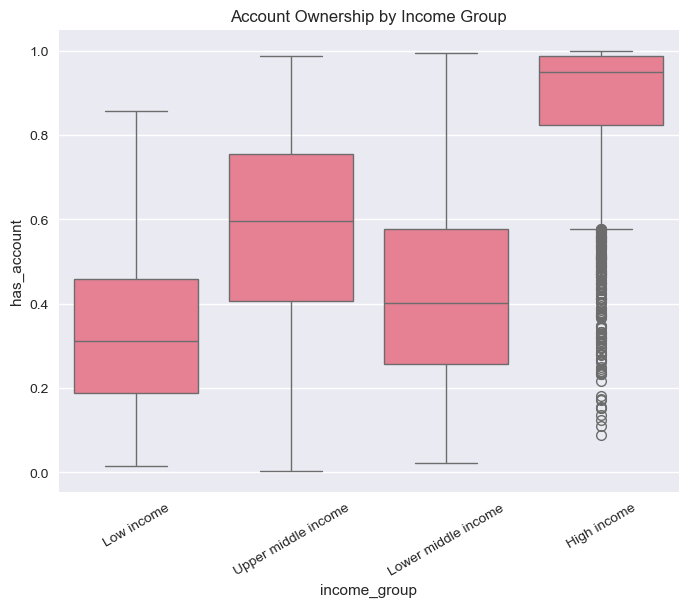

In [68]:
# =========================
# B. GROUP COMPARISONS
# =========================
# Boxplot: Account ownership by income group
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_clean, x="income_group", y="has_account")
plt.title("Account Ownership by Income Group")
plt.xticks(rotation=30)
plt.show()



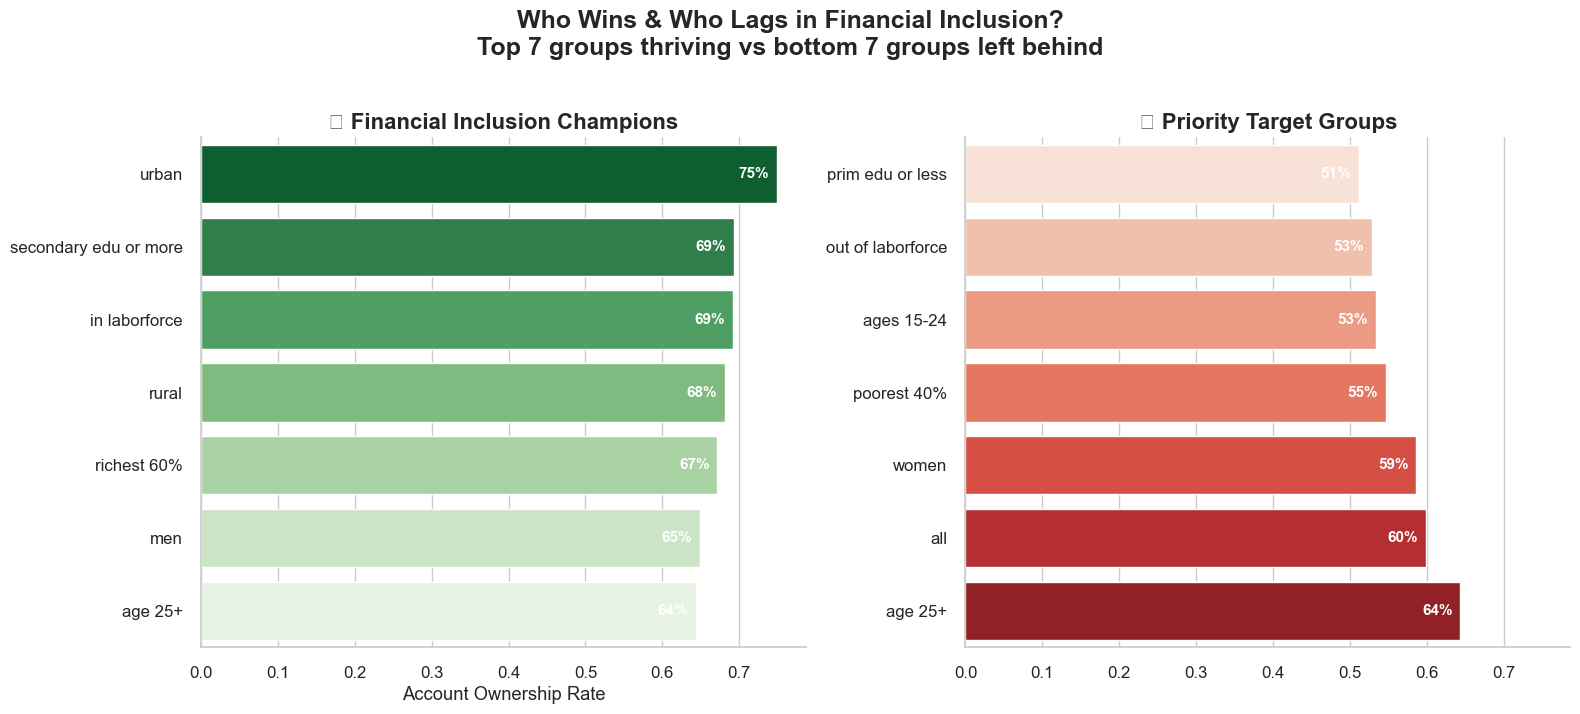

🏆 CHAMPION SEGMENTS:
 demo_subgroup
urban                    0.750
secondary edu or more    0.694
in laborforce            0.691
rural                    0.682
richest 60%              0.672
men                      0.649
age 25+                  0.644

🎯 EXCLUDED SEGMENTS:
 demo_subgroup
prim edu or less     0.512
out of laborforce    0.529
ages 15-24           0.534
poorest 40%          0.547
women                0.587
all                  0.599
age 25+              0.644


In [69]:
# ===============================================================
# DEMOGRAPHIC CHAMPIONS vs EXCLUDED - Who wins and who lags?
# ===============================================================

# Prepare subgroup statistics
demo_stats = df_clean.groupby('demo_subgroup')['has_account'].agg(['mean', 'count'])
demo_stats = demo_stats[demo_stats['count'] >= 10]

# Top & bottom segments
top_segments = demo_stats.nlargest(7, 'mean')
bottom_segments = demo_stats.nsmallest(7, 'mean')

# Set theme
sns.set_theme(style="whitegrid", font_scale=1.1)

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True)

# ---------------- Champions Plot ----------------
sns.barplot(
    x=top_segments['mean'],
    y=top_segments.index,
    palette="Greens_r",
    ax=axes[0]
)
axes[0].set_title("🏆 Financial Inclusion Champions", fontsize=16, weight='bold')
axes[0].set_xlabel("Account Ownership Rate")
axes[0].set_ylabel("")

# Add % labels inside bars
for i, v in enumerate(top_segments['mean']):
    axes[0].text(v - 0.05, i, f"{v:.0%}", va='center',
                 fontsize=11, color="white", weight="bold")

# ---------------- Excluded Plot ----------------
sns.barplot(
    x=bottom_segments['mean'],
    y=bottom_segments.index,
    palette="Reds",
    ax=axes[1]
)
axes[1].set_title("🎯 Priority Target Groups", fontsize=16, weight='bold')
axes[1].set_xlabel("")
axes[1].set_ylabel("")

# Add % labels inside bars
for i, v in enumerate(bottom_segments['mean']):
    axes[1].text(v - 0.05, i, f"{v:.0%}", va='center',
                 fontsize=11, color="white", weight="bold")

# ---------------- Final Touches ----------------
fig.suptitle(
    "Who Wins & Who Lags in Financial Inclusion?\n"
    "Top 7 groups thriving vs bottom 7 groups left behind",
    fontsize=18, weight='bold', y=1.02
)

sns.despine()
plt.tight_layout()
plt.show()

# Print results clearly
print("🏆 CHAMPION SEGMENTS:\n", top_segments['mean'].round(3).to_string())
print("\n🎯 EXCLUDED SEGMENTS:\n", bottom_segments['mean'].round(3).to_string())


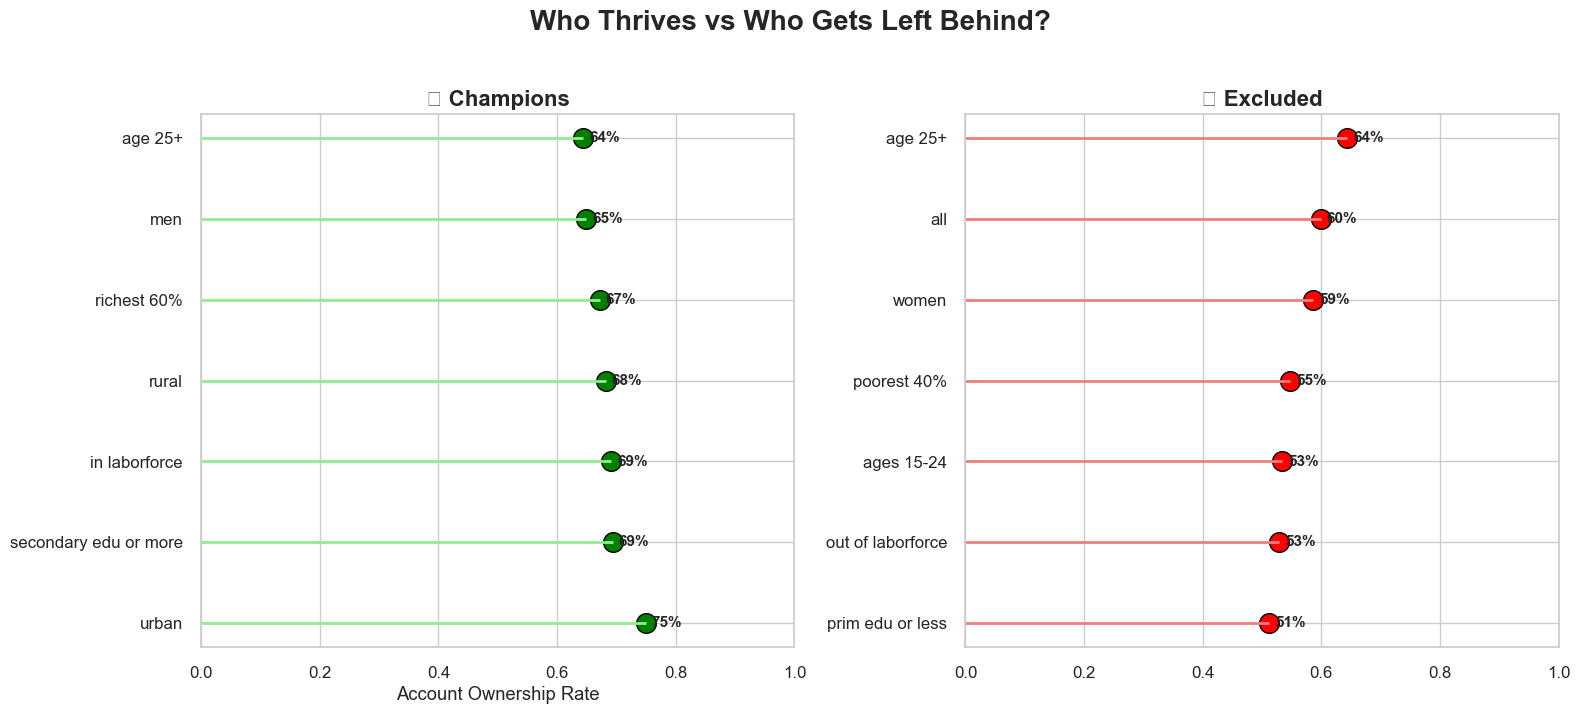

In [70]:
# Lollipop Chart for Champions vs Excluded
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True)

# Champions
axes[0].hlines(y=top_segments.index, xmin=0, xmax=top_segments['mean'], color="lightgreen", lw=2)
axes[0].scatter(top_segments['mean'], top_segments.index, color="green", s=200, edgecolors="black")
for i, v in enumerate(top_segments['mean']):
    axes[0].text(v + 0.01, i, f"{v:.0%}", va='center', fontsize=11, weight="bold")
axes[0].set_title("🏆 Champions", fontsize=16, weight="bold")
axes[0].set_xlabel("Account Ownership Rate")
axes[0].set_xlim(0, 1)

# Excluded
axes[1].hlines(y=bottom_segments.index, xmin=0, xmax=bottom_segments['mean'], color="lightcoral", lw=2)
axes[1].scatter(bottom_segments['mean'], bottom_segments.index, color="red", s=200, edgecolors="black")
for i, v in enumerate(bottom_segments['mean']):
    axes[1].text(v + 0.01, i, f"{v:.0%}", va='center', fontsize=11, weight="bold")
axes[1].set_title("🎯 Excluded", fontsize=16, weight="bold")
axes[1].set_xlabel("")
axes[1].set_xlim(0, 1)

# Global title
fig.suptitle("Who Thrives vs Who Gets Left Behind?", fontsize=20, weight="bold", y=1.02)

plt.tight_layout()
plt.show()


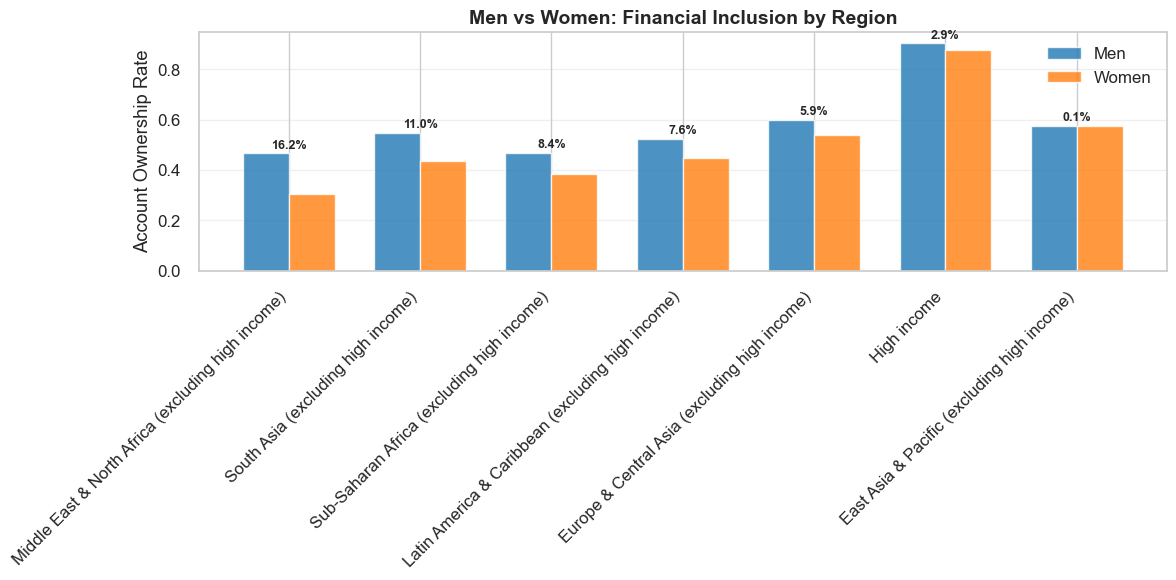

👥 GENDER GAP BY REGION (Men - Women):
region
Middle East & North Africa (excluding high income)    0.162
South Asia (excluding high income)                    0.110
Sub-Saharan Africa (excluding high income)            0.084
Latin America & Caribbean (excluding high income)     0.076
Europe & Central Asia (excluding high income)         0.059
High income                                           0.029
East Asia & Pacific (excluding high income)           0.001
Name: gap, dtype: float64
👥 GENDER GAP BY REGION (Men vs Women):
demo_subgroup                                         men  women    gap
region                                                                 
Middle East & North Africa (excluding high income)  0.466  0.303  0.162
South Asia (excluding high income)                  0.548  0.437  0.110
Sub-Saharan Africa (excluding high income)          0.468  0.383  0.084
Latin America & Caribbean (excluding high income)   0.524  0.448  0.076
Europe & Central Asia (excluding high 

In [71]:
# ===============================================================
# 3. GENDER GAP ANALYSIS - Side-by-side comparison
# ===============================================================

# Filter gender data (only men & women) from analysis dataset
gender_data = df_clean[df_clean['demo_subgroup'].isin(['men', 'women'])]

if not gender_data.empty:
    # Calculate average account ownership by region & gender
    gender_stats = (
        gender_data.groupby(['region', 'demo_subgroup'])['has_account']
        .mean()
        .unstack()
    )

    # Calculate gap (Men - Women)
    gender_stats['gap'] = gender_stats['men'] - gender_stats['women']
    gender_stats_sorted = gender_stats.sort_values('gap', ascending=False)

    # Plot side-by-side bars
    plt.figure(figsize=(12, 6))
    x = np.arange(len(gender_stats_sorted))
    bar_width = 0.35

    plt.bar(x - bar_width/2, gender_stats_sorted['men'], bar_width, label='Men', color='#1f77b4', alpha=0.8)
    plt.bar(x + bar_width/2, gender_stats_sorted['women'], bar_width, label='Women', color='#ff7f0e', alpha=0.8)

    # Annotate gap above bacacrs
    for i, gap in enumerate(gender_stats_sorted['gap']):
        plt.text(i, max(gender_stats_sorted['men'].iloc[i], gender_stats_sorted['women'].iloc[i]) + 0.02,
                 f"{gap:.1%}", ha='center', fontsize=9, fontweight='bold')

    plt.xticks(x, gender_stats_sorted.index, rotation=45, ha='right')
    plt.ylabel('Account Ownership Rate')
    plt.title('Men vs Women: Financial Inclusion by Region', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Print table
    print("👥 GENDER GAP BY REGION (Men - Women):")
    print(gender_stats_sorted['gap'].round(3))

    # Print table with men, women, and gap
    print("👥 GENDER GAP BY REGION (Men vs Women):")
    print(gender_stats_sorted[['men', 'women', 'gap']].round(3))


# (D). ***Handling the Missing Values***

- We will use a comprehensive pipeline, that will allow us to call on each function to display the results.
- This pipeline systematically prepares the dataset for analysis and modeling by combining **domain knowledge** and **data-driven missingness checks**.




## (a). ***Understand the data***
  
   
   * Each column is mapped to its **real-world meaning** (e.g., `has_account` = access to formal or digital accounts)
   * Missing values are profiled for each column.
   * Output: A dictionary of column meanings + % missing per feature.



In [72]:
def step1_understand_the_data(df):
    """
    Step 1: Understand what each renamed column represents
    """
    print("🔍 STEP 1: UNDERSTANDING THE DATA")
    print("="*60)
    
    # Meanings for cleaned column names
    column_meanings = {
        # Demographics
        'region': 'World Bank Region',
        'income_group': 'World Bank Income Group Classification',
        'demo_group': 'Demographic Group (e.g., age, gender, education)',
        'demo_subgroup': 'Secondary Demographic Group',
        
        # Core Financial Inclusion Indicators
        'has_account': 'Has Account (Traditional/Digital) - TARGET VARIABLE',
        'borrowed_any': 'Borrowed Any Money (Traditional/Digital)',
        'saved_any': 'Saved Any Money (Traditional/Digital)',
        
        # Credit/Debt
        'credit_card': 'Has Credit Card',
        'biz_loan_source': 'Business Loan Source',
        'biz_loan': 'Business Loan Taken',
        'loan_purpose_group': 'Grouped Loan Purpose',
        'loan_purpose': 'Specific Loan Purpose',
        
        # Savings Behaviour
        'saved_old_age': 'Saved for Old Age',
        'saved_for_purchase': 'Saved for a Purchase',
        'saved_no_purpose': 'Saved Without a Purpose',
        
        # Digital/Mobile Payments
        'mobile_pay_s_r': 'Mobile Payment Sending/Receiving',
        'digital_payment_other': 'Other Digital Payment',
        'mobile_payment': 'Mobile Payment Usage',
        'mobile_payment_bill': 'Mobile Bill Payment',
        
        # Government/Institutional Services
        'govt_digital_pay': 'Government Digital Payments',
        'govt_digital_pay_acc': 'Government Digital Payments via Account',
        'digital_pay': 'Digital Payments (General)',
        'digital_pay_acc': 'Digital Payments via Account',
        'govt_payment_recv': 'Government Payment Received',
        
        # Financial Resilience
        'fin_resilience': 'Financial Resilience / Ability to Cope',
        'emergency_funds': 'Emergency Funds Availability',
        
        # Digital Preference
        'prefer_digital_acc': 'Preference for Digital - Account Services',
        'prefer_digital_fin': 'Preference for Digital - Financial Services',
        'prefer_digital': 'Preference for Digital - General'
    }
    
    print("COLUMN INTERPRETATION:")
    print("-" * 60)
    for col in df.columns:
        meaning = column_meanings.get(col, "Unknown financial indicator")
        missing_pct = (df[col].isnull().sum() / len(df)) * 100
        print(f"{col:<22} | {missing_pct:>5.1f}% missing | {meaning}")
    
    return column_meanings


In [73]:
#Step 1: Understand the data
column_meanings = step1_understand_the_data(df_clean)
    

🔍 STEP 1: UNDERSTANDING THE DATA
COLUMN INTERPRETATION:
------------------------------------------------------------
region                 |   8.0% missing | World Bank Region
income_group           |   8.0% missing | World Bank Income Group Classification
demo_group             |   0.0% missing | Demographic Group (e.g., age, gender, education)
demo_subgroup          |   0.0% missing | Secondary Demographic Group
has_account            |   1.1% missing | Has Account (Traditional/Digital) - TARGET VARIABLE
borrowed_any           |  25.3% missing | Borrowed Any Money (Traditional/Digital)
credit_card            |  63.0% missing | Has Credit Card
biz_loan_source        |  27.7% missing | Business Loan Source
biz_loan               |  33.3% missing | Business Loan Taken
loan_purpose_group     |  42.2% missing | Grouped Loan Purpose
loan_purpose           |  46.3% missing | Specific Loan Purpose
saved_old_age          |  64.6% missing | Saved for Old Age
saved_for_purchase     |  24.8% mi

## (b). ***Categorize by Business Logic***
  
* Features are grouped into meaningful **business categories**:

  * Demographics
  * Core Inclusion
  * Credit Behaviour
  * Savings Behaviour
  * Digital Payments
  * Government Services
  * Financial Resilience
  * Digital Preference
* Missingness is summarized per group to highlight sparsity trends.



In [74]:
def step2_categorize_by_business_logic(df, column_meanings):
    """
    Step 2: Categorize columns by business importance and missing data
    """
    print(f"\n🏷️  STEP 2: CATEGORIZING BY BUSINESS LOGIC")
    print("="*60)
    
    categories = {
        'demographics': ['region', 'income_group', 'demo_group', 'demo_subgroup'],
        'core_inclusion': ['has_account', 'borrowed_any', 'saved_any'],
        'credit_behavior': ['credit_card', 'biz_loan_source', 'biz_loan', 'loan_purpose_group', 'loan_purpose'],
        'savings_behavior': ['saved_old_age', 'saved_for_purchase', 'saved_no_purpose'],
        'digital_payments': ['mobile_pay_s_r', 'digital_payment_other', 'mobile_payment', 'mobile_payment_bill'],
        'govt_services': ['govt_digital_pay', 'govt_digital_pay_acc', 'digital_pay', 'digital_pay_acc', 'govt_payment_recv'],
        'financial_resilience': ['fin_resilience', 'emergency_funds'],
        'digital_preference': ['prefer_digital_acc', 'prefer_digital_fin', 'prefer_digital']
    }
    
    print("BUSINESS CATEGORY ANALYSIS:")
    print("-" * 60)
    
    for category, cols in categories.items():
        available_cols = [col for col in cols if col in df.columns]
        if available_cols:
            avg_missing = np.mean([df[col].isnull().mean() for col in available_cols]) * 100
            print(f"{category.upper():<22} | {len(available_cols)} cols | {avg_missing:>5.1f}% avg missing")
            
            for col in available_cols:
                missing_pct = df[col].isnull().mean() * 100
                meaning = column_meanings.get(col, "Unknown")
                print(f"  └─ {col:<20} | {missing_pct:>5.1f}% missing | {meaning}")
    
    return categories


In [75]:
#Step 2: Categorize by business logic
categories = step2_categorize_by_business_logic(df_clean, column_meanings)
    


🏷️  STEP 2: CATEGORIZING BY BUSINESS LOGIC
BUSINESS CATEGORY ANALYSIS:
------------------------------------------------------------
DEMOGRAPHICS           | 4 cols |   4.0% avg missing
  └─ region               |   8.0% missing | World Bank Region
  └─ income_group         |   8.0% missing | World Bank Income Group Classification
  └─ demo_group           |   0.0% missing | Demographic Group (e.g., age, gender, education)
  └─ demo_subgroup        |   0.0% missing | Secondary Demographic Group
CORE_INCLUSION         | 3 cols |  17.2% avg missing
  └─ has_account          |   1.1% missing | Has Account (Traditional/Digital) - TARGET VARIABLE
  └─ borrowed_any         |  25.3% missing | Borrowed Any Money (Traditional/Digital)
  └─ saved_any            |  25.4% missing | Saved Any Money (Traditional/Digital)
CREDIT_BEHAVIOR        | 5 cols |  42.5% avg missing
  └─ credit_card          |  63.0% missing | Has Credit Card
  └─ biz_loan_source      |  27.7% missing | Business Loan Source
 

## (c). ***Missing Data Strategy***


* For each category, we are defining how to treat missing values using **business logic** from **step 2** and the **proportion of missingness**.


  * **Demographics** → Missing means *unknown profile*. If sparse → **drop**, else → **fill with mode**.
  * **Core Inclusion** → These are **key indicators**; missing means *no activity* → **fill with 0**.
  * **Digital Payments** → If not reported, assume *non-usage*. If moderate missingness → **0 + indicator**; if too sparse → **drop**. 
  * **Savings Behaviour** → Same as digital; missing = *no savings*. Apply **0 + indicator** or **drop** if very sparse.
  * **Credit Behaviour** → Missing means *no borrowing*. Use **0 + indicator**, or **drop** if sparse.
  * **Government Services** → Missing = *did not use service*. Apply **0 + indicator**, drop if highly missing.
  * **Financial Resilience** → Important behavioural signals. If moderate missing → **median**, if highly sparse → **drop**.
  * **Digital Preference** → Missing = *no preference stated*. Apply **0 + indicator**, drop if too sparse.

 ***Outcome***

Each column is mapped to a rule: `DROP`, `MODE`, `MEDIAN`, `ZERO`, or `ZERO_WITH_INDICATOR` — ensuring consistency and business relevance.

  * **DROP** → if too sparse (e.g., >60% missing).
  * **FILL with 0** → if missingness = “no activity” (e.g., no savings, no digital payments).
  * **FILL with 0 + Indicator** → if missingness itself carries information.
  * **FILL with MODE/MEDIAN** → for categorical or numeric features with moderate missingness.



In [76]:
def step3_missing_data_strategy(df, categories):
    """
    Step 3: Define domain-specific missing data strategy
    """
    print(f"\n🎯 STEP 3: MISSING DATA STRATEGY")
    print("="*60)
    
    strategy = {}
    
    print("STRATEGY BY CATEGORY:")
    print("-" * 60)
    
    # Demographics: Missing = Unknown, but drop if too sparse
    for col in categories['demographics']:
        if col in df.columns:
            missing_pct = df[col].isnull().mean()
            if missing_pct > 0.3:
                strategy[col] = 'DROP'
                print(f"{col:<20} | DROP (>{missing_pct:.1%} missing)")
            else:
                strategy[col] = 'MODE'
                print(f"{col:<20} | FILL with MODE")
    
    # Core inclusion: These are crucial, missing = 0 (no activity)
    for col in categories['core_inclusion']:
        if col in df.columns:
            strategy[col] = 'ZERO'
            print(f"{col:<20} | FILL with 0 (no activity)")
    
    # Digital usage: Missing = 0 (doesn't use digital)
    for col in categories['digital_payments']:
        if col in df.columns:
            missing_pct = df[col].isnull().mean()
            if missing_pct > 0.6:
                strategy[col] = 'DROP'
                print(f"{col:<20} | DROP (>{missing_pct:.1%} missing)")
            else:
                strategy[col] = 'ZERO_WITH_INDICATOR'
                print(f"{col:<20} | FILL with 0 + create indicator")
    
    # Savings: Missing = 0 (no savings activity)
    for col in categories['savings_behavior']:
        if col in df.columns:
            missing_pct = df[col].isnull().mean()
            if missing_pct > 0.6:
                strategy[col] = 'DROP'
                print(f"{col:<20} | DROP (>{missing_pct:.1%} missing)")
            else:
                strategy[col] = 'ZERO_WITH_INDICATOR'
                print(f"{col:<20} | FILL with 0 + create indicator")
    
    # Credit: Missing = 0 (no credit activity)
    for col in categories['credit_behavior']:
        if col in df.columns:
            missing_pct = df[col].isnull().mean()
            if missing_pct > 0.5:
                strategy[col] = 'DROP'
                print(f"{col:<20} | DROP (>{missing_pct:.1%} missing)")
            else:
                strategy[col] = 'ZERO_WITH_INDICATOR'
                print(f"{col:<20} | FILL with 0 + create indicator")
    
    # Government services: Missing = 0 (doesn't use govt services)
    for col in categories['govt_services']:
        if col in df.columns:
            missing_pct = df[col].isnull().mean()
            if missing_pct > 0.6:
                strategy[col] = 'DROP'
                print(f"{col:<20} | DROP (>{missing_pct:.1%} missing)")
            else:
                strategy[col] = 'ZERO_WITH_INDICATOR'
                print(f"{col:<20} | FILL with 0 + create indicator")
    
    # Financial resilience: Important to keep
    for col in categories['financial_resilience']:
        if col in df.columns:
            missing_pct = df[col].isnull().mean()
            if missing_pct > 0.5:
                strategy[col] = 'DROP'
                print(f"{col:<20} | DROP (>{missing_pct:.1%} missing)")
            else:
                strategy[col] = 'MEDIAN'
                print(f"{col:<20} | FILL with MEDIAN")
    
    # Digital preference: Missing = 0 (no digital preference)
    for col in categories['digital_preference']:
        if col in df.columns:
            missing_pct = df[col].isnull().mean()
            if missing_pct > 0.6:
                strategy[col] = 'DROP'
                print(f"{col:<20} | DROP (>{missing_pct:.1%} missing)")
            else:
                strategy[col] = 'ZERO_WITH_INDICATOR'
                print(f"{col:<20} | FILL with 0 + create indicator")
    
    return strategy

In [77]:
# Step 3: Define missing data strategy
strategy = step3_missing_data_strategy(df_clean, categories)
    


🎯 STEP 3: MISSING DATA STRATEGY
STRATEGY BY CATEGORY:
------------------------------------------------------------
region               | FILL with MODE
income_group         | FILL with MODE
demo_group           | FILL with MODE
demo_subgroup        | FILL with MODE
has_account          | FILL with 0 (no activity)
borrowed_any         | FILL with 0 (no activity)
saved_any            | FILL with 0 (no activity)
mobile_pay_s_r       | FILL with 0 + create indicator
digital_payment_other | FILL with 0 + create indicator
mobile_payment       | DROP (>60.5% missing)
mobile_payment_bill  | FILL with 0 + create indicator
saved_old_age        | DROP (>64.6% missing)
saved_for_purchase   | FILL with 0 + create indicator
saved_no_purpose     | FILL with 0 + create indicator
credit_card          | DROP (>63.0% missing)
biz_loan_source      | FILL with 0 + create indicator
biz_loan             | FILL with 0 + create indicator
loan_purpose_group   | FILL with 0 + create indicator
loan_purpose     



## (d). ***Apply Cleaning Strategy***
  
* Columns marked as **DROP** are removed.
* Columns marked as **FILL** are imputed with appropriate values.
* Missingness indicators are created where relevant (e.g., `mobile_payment_was_missing`).
* A **cleaning log** is generated for full transparency.

---

In [78]:

def step4_apply_cleaning_strategy(df, strategy):
    """
    Step 4: Apply the cleaning strategy
    """
    print(f"\n🧹 STEP 4: APPLYING CLEANING STRATEGY")
    print("="*60)
    
    df_clean = df.copy()
    cleaning_log = []
    
    for col, action in strategy.items():
        if col not in df_clean.columns:
            continue
            
        missing_count = df_clean[col].isnull().sum()
        
        if action == 'DROP':
            df_clean.drop(col, axis=1, inplace=True)
            print(f"✂️  DROPPED: {col}")
            cleaning_log.append(f"DROPPED {col} (too sparse)")
            
        elif action == 'ZERO':
            df_clean[col].fillna(0, inplace=True)
            print(f"0️⃣  FILLED with 0: {col} ({missing_count} values)")
            cleaning_log.append(f"FILLED {col} with 0 ({missing_count} missing)")
            
        elif action == 'ZERO_WITH_INDICATOR':
            # Create indicator for missingness
            df_clean[f'{col}_was_missing'] = df_clean[col].isnull().astype(int)
            df_clean[col].fillna(0, inplace=True)
            print(f"0️⃣🏷️  FILLED with 0 + indicator: {col} ({missing_count} values)")
            cleaning_log.append(f"FILLED {col} with 0 + created missing indicator ({missing_count} missing)")
            
        elif action == 'MODE':
            mode_val = df_clean[col].mode()
            fill_val = mode_val.iloc[0] if len(mode_val) > 0 else 'Unknown'
            df_clean[col].fillna(fill_val, inplace=True)
            print(f"📊 FILLED with MODE: {col} = {fill_val} ({missing_count} values)")
            cleaning_log.append(f"FILLED {col} with mode {fill_val} ({missing_count} missing)")
            
        elif action == 'MEDIAN':
            median_val = df_clean[col].median()
            df_clean[col].fillna(median_val, inplace=True)
            print(f"📊 FILLED with MEDIAN: {col} = {median_val} ({missing_count} values)")
            cleaning_log.append(f"FILLED {col} with median {median_val} ({missing_count} missing)")
    
    return df_clean, cleaning_log

In [79]:
# Step 4: Apply cleaning strategy
df_cleaned, cleaning_log = step4_apply_cleaning_strategy(df_clean, strategy)
    


🧹 STEP 4: APPLYING CLEANING STRATEGY
📊 FILLED with MODE: region = High income (684 values)
📊 FILLED with MODE: income_group = High income (684 values)
📊 FILLED with MODE: demo_group = age_cat (0 values)
📊 FILLED with MODE: demo_subgroup = all (0 values)
0️⃣  FILLED with 0: has_account (90 values)
0️⃣  FILLED with 0: borrowed_any (2165 values)
0️⃣  FILLED with 0: saved_any (2175 values)
0️⃣🏷️  FILLED with 0 + indicator: mobile_pay_s_r (4627 values)
0️⃣🏷️  FILLED with 0 + indicator: digital_payment_other (2357 values)
✂️  DROPPED: mobile_payment
0️⃣🏷️  FILLED with 0 + indicator: mobile_payment_bill (3636 values)
✂️  DROPPED: saved_old_age
0️⃣🏷️  FILLED with 0 + indicator: saved_for_purchase (2122 values)
0️⃣🏷️  FILLED with 0 + indicator: saved_no_purpose (3486 values)
✂️  DROPPED: credit_card
0️⃣🏷️  FILLED with 0 + indicator: biz_loan_source (2375 values)
0️⃣🏷️  FILLED with 0 + indicator: biz_loan (2855 values)
0️⃣🏷️  FILLED with 0 + indicator: loan_purpose_group (3611 values)
0️⃣🏷️  FI


## (e). ***Validate & Summarize***

* Compare **before vs after** dataset shapes and missingness counts.
* Confirm rows are retained and columns reduced only when necessary.
* Show **total missing values reduced**.
* List all **cleaning actions taken** for reproducibility.
* Check target variable (`has_account`) distribution to ensure no distortion.

---

***Final Output***: 

- A dataset that is **clean, consistent, and ready for modeling**, with full documentation of the cleaning process.

In [80]:

def step5_validate_and_summarize(original_df, cleaned_df, cleaning_log):
    """
    Step 5: Validate the cleaning results
    """
    print(f"\n✅ STEP 5: VALIDATION & SUMMARY")
    print("="*60)
    
    print("BEFORE vs AFTER:")
    print(f"  Original shape: {original_df.shape}")
    print(f"  Cleaned shape:  {cleaned_df.shape}")
    print(f"  Columns dropped: {original_df.shape[1] - cleaned_df.shape[1]}")
    print(f"  Rows retained: {cleaned_df.shape[0]/original_df.shape[0]:.1%}")
    
    print(f"\nMISSING VALUES:")
    print(f"  Original: {original_df.isnull().sum().sum():,}")
    print(f"  Cleaned:  {cleaned_df.isnull().sum().sum():,}")
    
    print(f"\nCLEANING ACTIONS TAKEN:")
    for i, action in enumerate(cleaning_log, 1):
        print(f"  {i:2d}. {action}")
    
    return True


In [81]:
# Step 5: Validate and summarize
step5_validate_and_summarize(df_clean, df_cleaned, cleaning_log)
    


✅ STEP 5: VALIDATION & SUMMARY
BEFORE vs AFTER:
  Original shape: (8566, 29)
  Cleaned shape:  (8566, 37)
  Columns dropped: -8
  Rows retained: 100.0%

MISSING VALUES:
  Original: 96,939
  Cleaned:  0

CLEANING ACTIONS TAKEN:
   1. FILLED region with mode High income (684 missing)
   2. FILLED income_group with mode High income (684 missing)
   3. FILLED demo_group with mode age_cat (0 missing)
   4. FILLED demo_subgroup with mode all (0 missing)
   5. FILLED has_account with 0 (90 missing)
   6. FILLED borrowed_any with 0 (2165 missing)
   7. FILLED saved_any with 0 (2175 missing)
   8. FILLED mobile_pay_s_r with 0 + created missing indicator (4627 missing)
   9. FILLED digital_payment_other with 0 + created missing indicator (2357 missing)
  10. DROPPED mobile_payment (too sparse)
  11. FILLED mobile_payment_bill with 0 + created missing indicator (3636 missing)
  12. DROPPED saved_old_age (too sparse)
  13. FILLED saved_for_purchase with 0 + created missing indicator (2122 missing

True

In [82]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8566 entries, 0 to 8565
Data columns (total 37 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   region                             8566 non-null   object 
 1   income_group                       8566 non-null   object 
 2   demo_group                         8566 non-null   object 
 3   demo_subgroup                      8566 non-null   object 
 4   has_account                        8566 non-null   float64
 5   borrowed_any                       8566 non-null   float64
 6   biz_loan_source                    8566 non-null   float64
 7   biz_loan                           8566 non-null   float64
 8   loan_purpose_group                 8566 non-null   float64
 9   loan_purpose                       8566 non-null   float64
 10  saved_for_purchase                 8566 non-null   float64
 11  saved_no_purpose                   8566 non-null   float

# (E). ***Exploratory Data Analysis (EDA)***

To understand the dataset and prepare it for deeper modeling, we follow a structured EDA process:

### **Steps in the Full EDA**
- **Descriptive Analysis** – Examine the structure, size, completeness, and basic distributions of the data.
- **Diagnostic Analysis** – Identify key gaps, disparities, and drivers behind the target variable.
- **Predictive Preparation** – Feature engineering, correlation checks, and initial model readiness.
- **Prescriptive Insights** – Translate findings into actionable recommendations or next steps.

---

## (a) . ***Descriptive EDA Tasks***

- **Dataset Overview**: Check total rows, columns, number of missing values, and fully complete records.  
- **Data Types Distribution**: Visualize the proportion of numerical (`int64`, `float64`) and categorical (`object`) features.  
- **Target Distribution**: Plot the distribution of the target variable (`has_account`) and mark the overall mean to see balance or skew.  
- **Missing Data Check**: Confirm the presence or absence of missing data.

---

### ***Key Observations***
- The dataset contains **~8,500 rows** with **no missing data**, ensuring clean input for modeling.
- Data types are predominantly **numeric (≈89%)**, with a small share of categorical features (~11%).
- The target variable `has_account` shows a **mean ownership rate of ~60%**, indicating a moderate class imbalance but no severe skew.
- These findings suggest the dataset is **ready for deeper diagnostic analysis** without immediate need for heavy data cleaning.


In [83]:
def descriptive_overview(df, target='has_account'):
    """
    DESCRIPTIVE ANALYTICS: Basic dataset statistics and structure
    Shows: dataset dimensions, data types, target distribution, missing data
    """
    print("📊 DESCRIPTIVE ANALYTICS - WHAT HAPPENED?")
    print("=" * 60)

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Dataset dimensions
    stats_data = {
        'Rows': df.shape[0],
        'Columns': df.shape[1],
        'Missing Values': df.isnull().sum().sum(),
        'Complete Records': df.dropna().shape[0]
    }
    axes[0,0].bar(stats_data.keys(), stats_data.values(), 
                  color=['skyblue','lightgreen','salmon','gold'])
    axes[0,0].set_title('Dataset Overview', fontweight='bold')
    axes[0,0].tick_params(axis='x', rotation=45)

    # Data types distribution
    dtype_counts = df.dtypes.value_counts()
    axes[0,1].pie(dtype_counts.values, labels=dtype_counts.index, autopct='%1.1f%%')
    axes[0,1].set_title('Data Types Distribution', fontweight='bold')

    # Target distribution
    if target in df.columns:
        target_data = df[target].dropna()
        axes[1,0].hist(target_data, bins=30, alpha=0.7, color='steelblue', edgecolor='black')
        axes[1,0].axvline(target_data.mean(), color='red', linestyle='--', 
                          label=f'Mean: {target_data.mean():.1%}')
        axes[1,0].set_title(f'Target Distribution ({target})', fontweight='bold')
        axes[1,0].legend()

    # Missing data heatmap
    missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
    missing_pct = missing_pct[missing_pct > 0]
    if len(missing_pct) > 0:
        y_pos = np.arange(len(missing_pct))
        axes[1,1].barh(y_pos, missing_pct.values, color='coral')
        axes[1,1].set_yticks(y_pos)
        axes[1,1].set_yticklabels(missing_pct.index)
        axes[1,1].set_title('Missing Data by Column (%)', fontweight='bold')
        axes[1,1].set_xlabel('Percentage Missing')
    else:
        axes[1,1].text(0.5, 0.5, 'No Missing Data!',
                       ha='center', va='center', fontsize=14, fontweight='bold')
        axes[1,1].axis('off')

    plt.tight_layout()
    plt.show()

    # Print summary
    print(f"\n📈 KEY METRICS:")
    print(f"• Total Records: {df.shape[0]:,}")
    print(f"• Features: {df.shape[1]}")
    if target in df.columns:
        print(f"• Target Mean: {df[target].mean():.1%}")
    print(f"• Completeness: {(df.dropna().shape[0]/df.shape[0]):.1%}")


📊 DESCRIPTIVE ANALYTICS - WHAT HAPPENED?


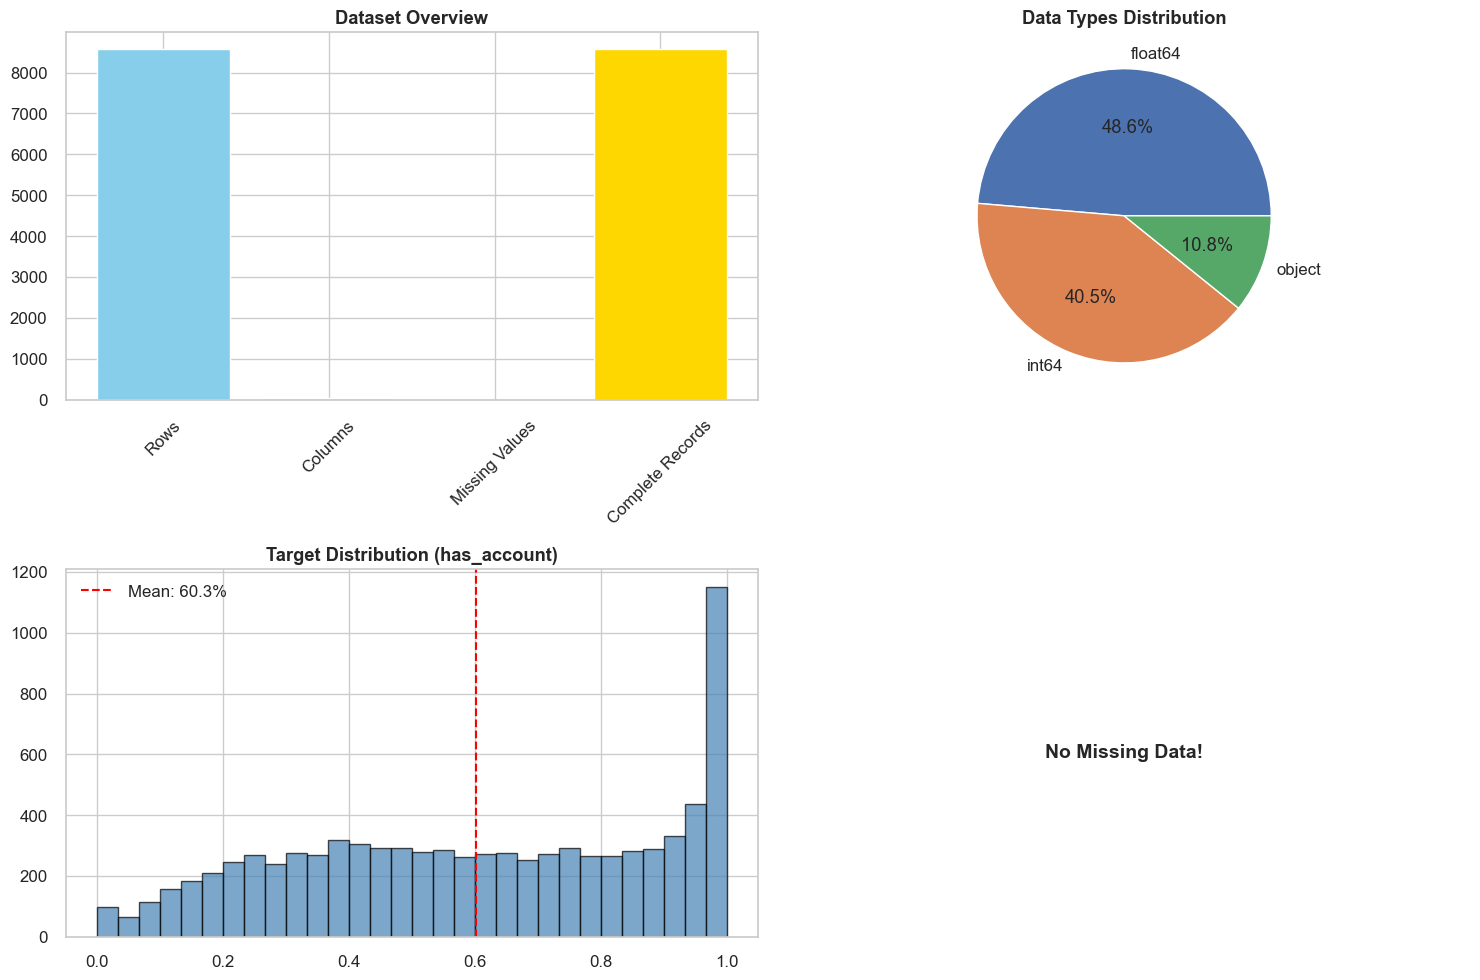


📈 KEY METRICS:
• Total Records: 8,566
• Features: 37
• Target Mean: 60.3%
• Completeness: 100.0%


In [84]:
# Descriptive overview of cleaned data
descriptive_overview(df_cleaned, target='has_account')

## (b). ***Demographic Representation***

This section explores **who** is represented in the dataset and highlights key demographic patterns.

---

### 1️. Dimensions of Demographic Representation
- **Regional Presence**: Geographical spread of sampled respondents.
- **Income Group Coverage**: Socio-economic segmentation across World Bank income classifications.
- **Population Subgroups**: Representation by education, workforce status, age, and gender.

---

### Descriptive Insights

#### Sample Distribution by Region
- **High-income economies dominate** the sample (~39%), followed by **Sub-Saharan Africa (~22%)** and **Europe & Central Asia (~12%)**.  
- Other regions—Latin America & Caribbean (~11%), East Asia & Pacific (~6%), Middle East & North Africa (~6%), and South Asia (~4%)—are **less represented**, suggesting possible geographic bias.

#### Sample Distribution by Income Group
- **High-income** countries again account for the largest share of respondents, exceeding **3,000 observations**.
- **Lower-middle income** and **upper-middle income** follow, while **low-income countries are under-sampled**, highlighting an imbalance in global financial inclusion data.

#### Top 10 Demographic Subgroups (by sample size)
- **Poverty status**: “Poorest 40%” and “Richest 60%” each form a sizable fraction, enabling inequality comparisons.
- **Labor force status**: Both “in laborforce” and “out of laborforce” groups are well represented.
- **Education**: “Primary or less” and “Secondary or more” have near-equal counts, allowing analysis of educational effects.
- **Age & Gender**: Men and women, as well as age brackets (15–24 vs 25+), are roughly balanced.

#### Account Ownership by Demographics
- **Urban residents** exhibit the highest financial account ownership (~0.7 rate).
- **Secondary education or more** and **labor force participation** are strong positive correlates of account ownership.
- **Rural** and **low-income subgroups** lag behind, indicating key targets for inclusion efforts.

---

### Key Takeaways
- The dataset leans toward **high-income and urban populations**, which may bias global generalizations.
- **Education, urbanization, and labor participation** are the strongest demographic drivers of account ownership.
- Future analyses should **weight or stratify** to avoid overestimating financial inclusion in under-represented groups.


In [85]:
def descriptive_demographics(df, target='has_account'):
    """
    DEMOGRAPHIC REPRESENTATION
    Shows sample distribution by region, income group, demographics,
    and ownership rates within subgroups.
    """
    print("\n👥 DEMOGRAPHIC REPRESENTATION")
    print("-" * 40)

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    if 'region' in df.columns:
        region_counts = df['region'].value_counts()
        axes[0,0].pie(region_counts.values, labels=region_counts.index, autopct='%1.1f%%')
        axes[0,0].set_title('Sample Distribution by Region', fontweight='bold')

    if 'income_group' in df.columns:
        income_counts = df['income_group'].value_counts()
        sns.barplot(x=income_counts.values, y=income_counts.index, ax=axes[0,1], palette='viridis')
        axes[0,1].set_title('Sample Distribution by Income Group', fontweight='bold')

    if 'demo_subgroup' in df.columns:
        demo_counts = df['demo_subgroup'].value_counts().head(10)
        axes[1,0].barh(range(len(demo_counts)), demo_counts.values)
        axes[1,0].set_yticks(range(len(demo_counts)))
        axes[1,0].set_yticklabels(demo_counts.index)
        axes[1,0].set_title('Top 10 Demographic Subgroups', fontweight='bold')

    if {'demo_subgroup', target}.issubset(df.columns):
        demo_target = df.groupby('demo_subgroup')[target].mean().sort_values(ascending=False).head(8)
        sns.barplot(x=demo_target.values, y=demo_target.index, ax=axes[1,1], palette='plasma')
        axes[1,1].set_title('Account Ownership by Demographics', fontweight='bold')
        axes[1,1].set_xlabel('Ownership Rate')

    plt.tight_layout()
    plt.show()



👥 DEMOGRAPHIC REPRESENTATION
----------------------------------------


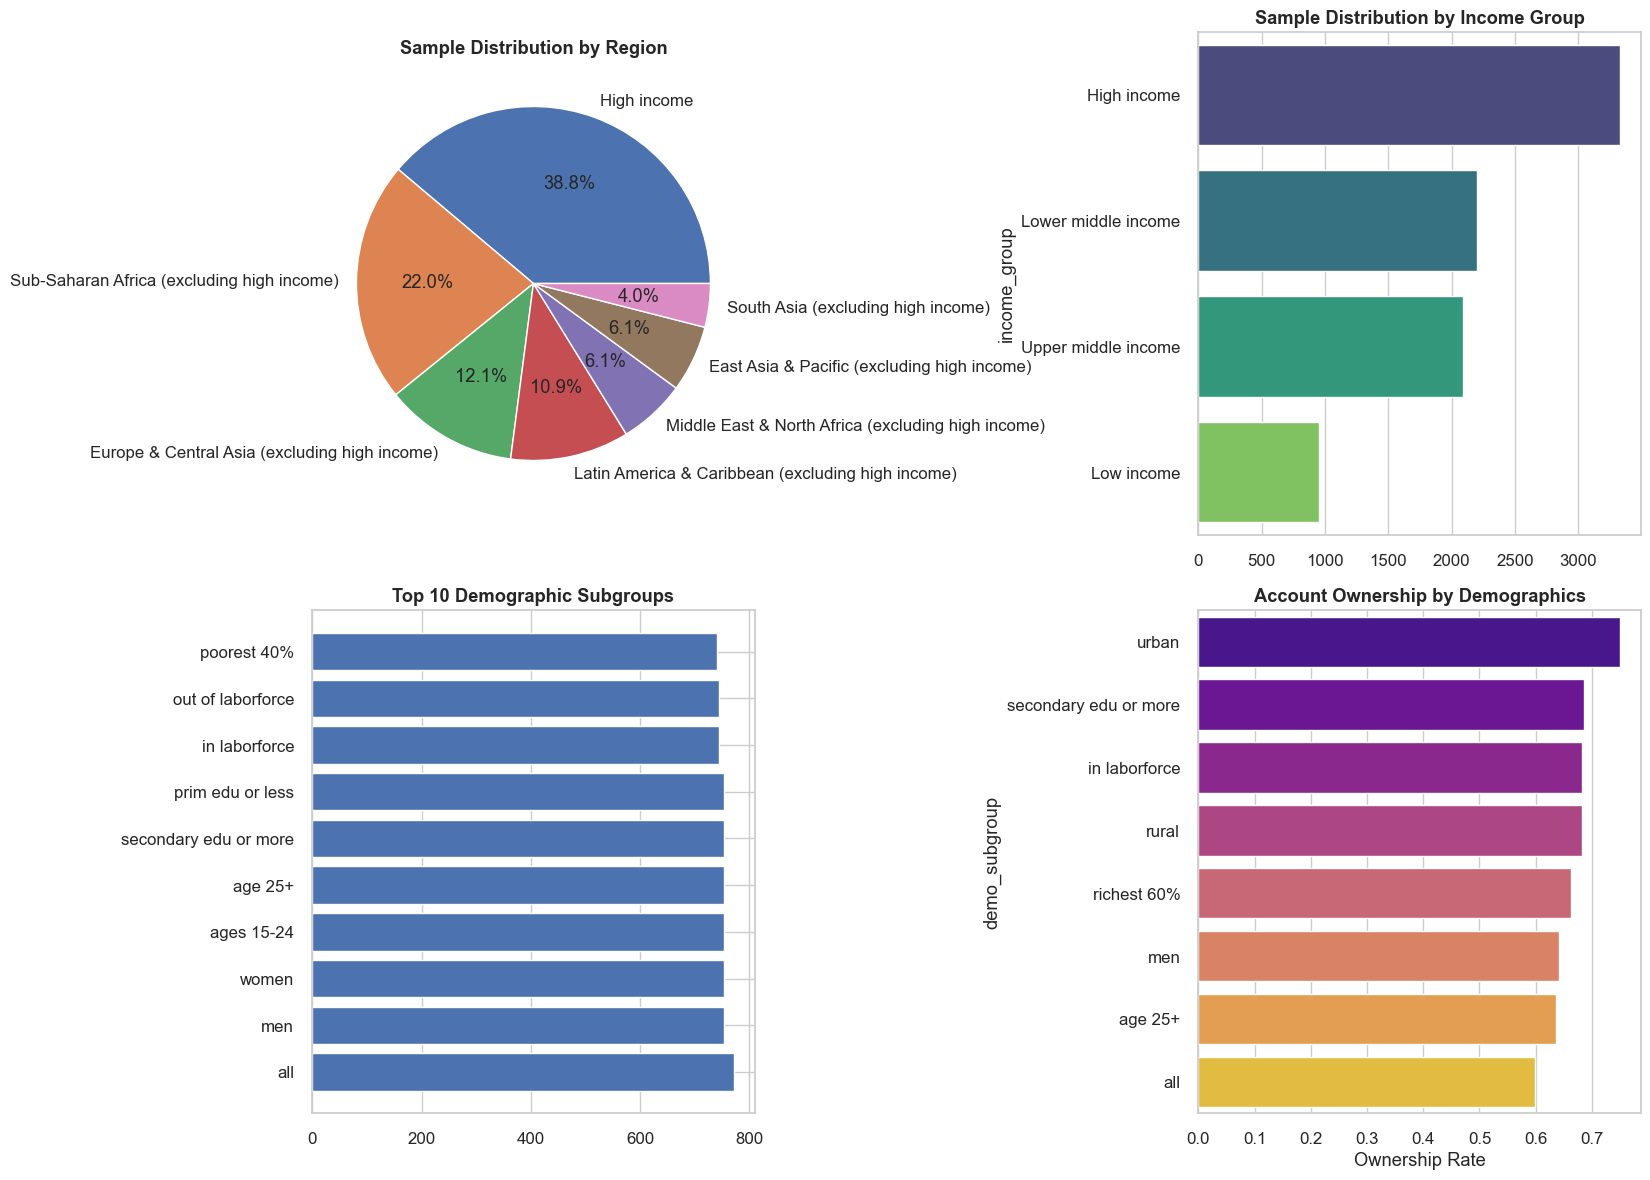

In [86]:
# Descriptive demographics analysis
descriptive_demographics(df_cleaned, target='has_account')


# (c). ***Diagnostic Analytics*** 


This function performs **diagnostic analytics** to uncover *why* disparities in financial account ownership exist across key socio-economic groups.  
It takes a dataframe and a target variable (default: `has_account`) and generates a series of focused visualizations.

---

1. **Income Gap Analysis**  
   - Groups by `income_group` and compares mean ownership rates.  
   - Highlights the **gap between the highest and lowest income groups** directly on the chart.

2. **Gender Gap by Region**  
   - Pivots data for `men` and `women` within each region.  
   - Plots side-by-side bars to show **regional gender disparities**.

3. **Regional Inequality**  
   - Ranks regions by their overall account ownership rate.  
   - Visualizes **cross-region differences** in financial inclusion.

4. **Champion Demographic Segments**  
   - Identifies top 7 demographic subgroups with the **highest ownership rates**.

5. **Priority/Excluded Segments**  
   - Highlights bottom 7 subgroups with the **lowest ownership rates** (high-priority for intervention).

---

#### **Observations**
- **Income Gap**: High-income countries exhibit a **51%+ higher ownership rate** than low-income ones.  
- **Gender Gap**: The largest disparities occur in the **Middle East & North Africa (16.2%)** and **South Asia (11.0%)**, while East Asia shows almost **no gap**.  
- **Regional Inequality**: High-income economies consistently lead in financial inclusion, with Sub-Saharan Africa and South Asia trailing.  
- **Champions**: Segments such as **urban residents (75%)** and those with **secondary education or more (69%)** show the strongest inclusion.  
- **Excluded Groups**: **Poorest 40%, youth (15–24), and women** have the lowest account ownership rates and need targeted strategies.




In [87]:

def diagnostic_gaps(df, target='has_account'):
    """
    DIAGNOSTIC ANALYTICS: Identify and visualize key gaps
    Improved layout with separate plots and clearer labels.
    """
    print("\n🔍 DIAGNOSTIC ANALYTICS - WHY DID IT HAPPEN?")
    print("=" * 60)

    # Income gap
    if 'income_group' in df.columns:
        plt.figure(figsize=(8,6))
        income_stats = df.groupby('income_group')[target].agg(['mean','count']).sort_values('mean', ascending=False)
        plt.bar(income_stats.index, income_stats['mean'],
                color=['darkgreen','orange','red','gray'][:len(income_stats)])
        plt.title('💰 Income Gap (Account Ownership Rate)', fontweight='bold')
        plt.ylabel('Ownership Rate')
        plt.xticks(rotation=20, ha='right')
        if len(income_stats) >= 2:
            gap = income_stats['mean'].iloc[0] - income_stats['mean'].iloc[-1]
            plt.text(0.5,0.9,f'Gap: {gap:.1%}',transform=plt.gca().transAxes,
                     fontsize=12,bbox=dict(boxstyle="round",facecolor='wheat'))
        plt.tight_layout()
        plt.show()

    # Gender gap
    if {'demo_subgroup','region'}.issubset(df.columns):
        gender_data = df[df['demo_subgroup'].isin(['men','women'])]
        if not gender_data.empty:
            gender_pivot = gender_data.pivot_table(values=target, index='region',
                                                   columns='demo_subgroup', aggfunc='mean')
            if {'men','women'}.issubset(gender_pivot.columns):
                gender_pivot['gap'] = gender_pivot['men'] - gender_pivot['women']
                x = np.arange(len(gender_pivot))
                width = 0.35
                plt.figure(figsize=(10,6))
                plt.bar(x - width/2, gender_pivot['men'], width, label='Men')
                plt.bar(x + width/2, gender_pivot['women'], width, label='Women')
                plt.xticks(x, gender_pivot.index, rotation=30, ha='right')
                plt.title('⚖️ Gender Gap by Region', fontweight='bold')
                plt.ylabel('Ownership Rate')
                plt.legend()
                plt.tight_layout()
                plt.show()

    # Regional inequality
    if 'region' in df.columns:
        plt.figure(figsize=(10,6))
        region_stats = df.groupby('region')[target].mean().sort_values(ascending=False)
        colors = plt.cm.RdYlGn(np.linspace(0.2,0.8,len(region_stats)))
        plt.bar(region_stats.index, region_stats.values, color=colors)
        plt.xticks(rotation=30, ha='right')
        plt.title('🌍 Regional Inequality in Ownership Rate', fontweight='bold')
        plt.ylabel('Ownership Rate')
        plt.tight_layout()
        plt.show()

    # Champions plot
    if 'demo_subgroup' in df.columns:
        demo_stats = df.groupby('demo_subgroup')[target].agg(['mean','count'])
        demo_stats = demo_stats[demo_stats['count'] >= 50]
        champions = demo_stats.nlargest(7, 'mean')
        if not champions.empty:
            plt.figure(figsize=(8,6))
            y = np.arange(len(champions))
            plt.hlines(y, 0, champions['mean'], colors='green', linewidth=3)
            plt.scatter(champions['mean'], y, color='darkgreen', s=100)
            plt.yticks(y, champions.index)
            plt.title('🏆 Top Champions (Highest Ownership)', fontweight='bold')
            plt.xlabel('Ownership Rate')
            plt.tight_layout()
            plt.show()

        # Priority/Excluded plot
        excluded  = demo_stats.nsmallest(7, 'mean')
        if not excluded.empty:
            plt.figure(figsize=(8,6))
            y = np.arange(len(excluded))
            plt.hlines(y, 0, excluded['mean'], colors='red', linewidth=3)
            plt.scatter(excluded['mean'], y, color='darkred', s=100)
            plt.yticks(y, excluded.index)
            plt.title('🎯 Priority Groups (Lowest Ownership)', fontweight='bold')
            plt.xlabel('Ownership Rate')
            plt.tight_layout()
            plt.show()



🔍 DIAGNOSTIC ANALYTICS - WHY DID IT HAPPEN?


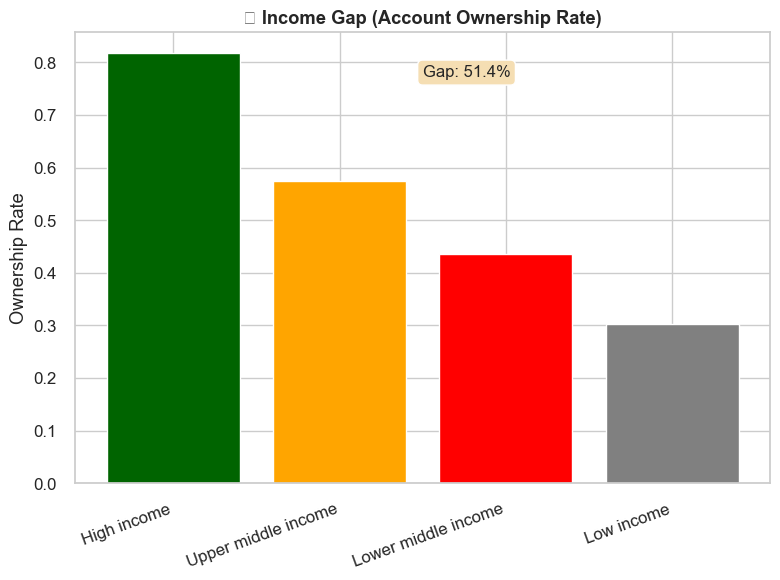

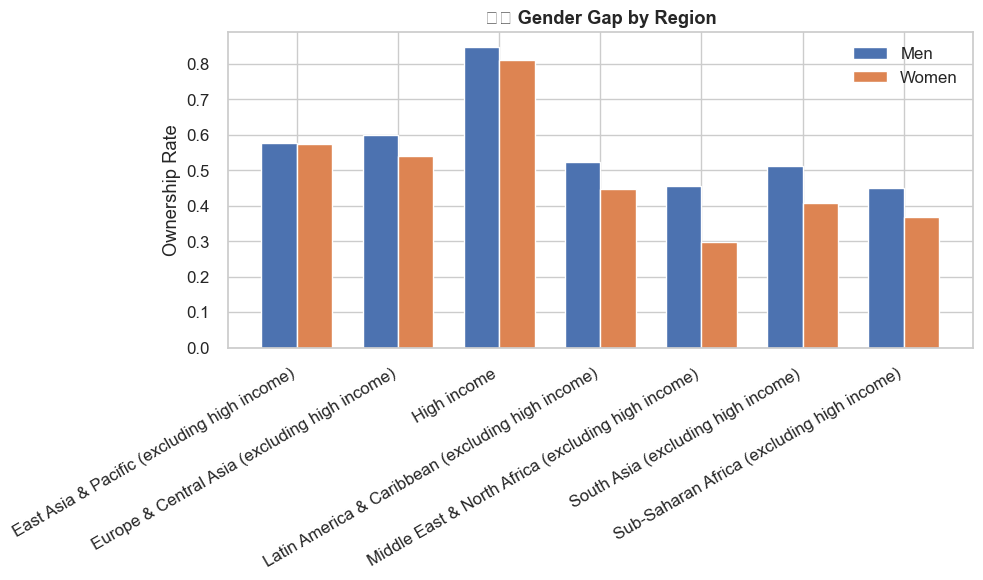

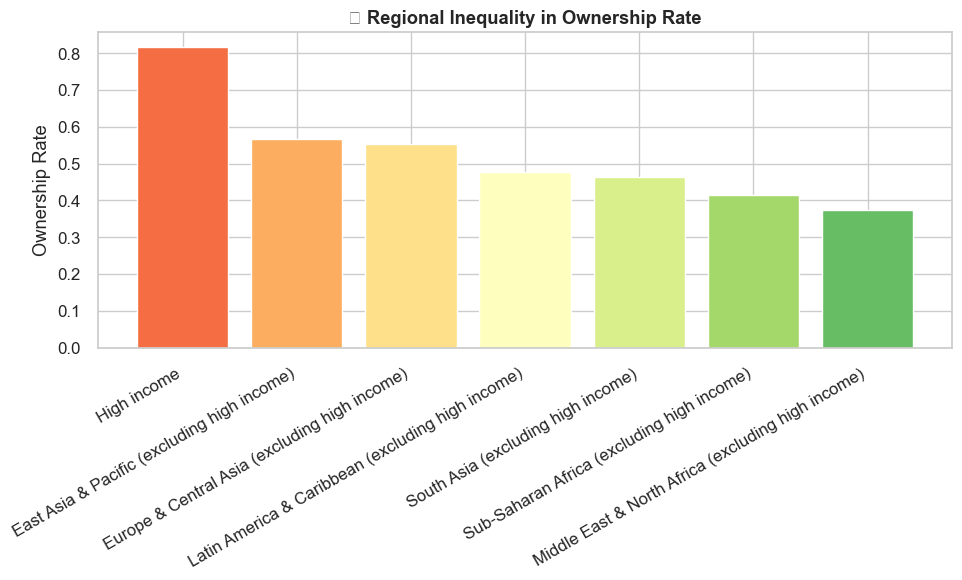

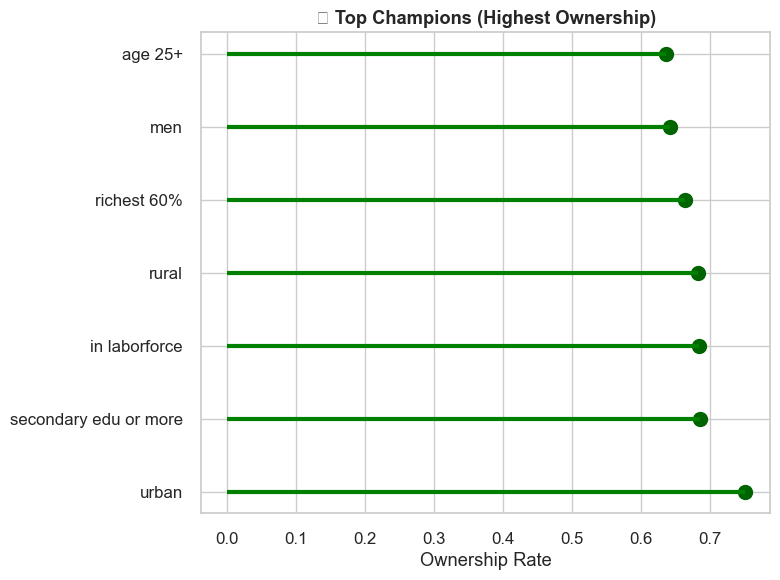

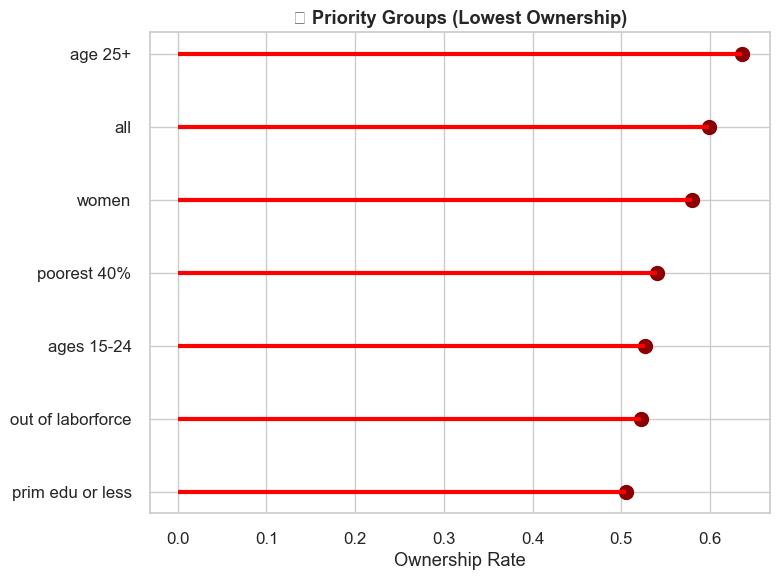

In [88]:
# diagnostic gaps analysis
diagnostic_gaps(df_cleaned, target='has_account')

## (d). ***Diagnostic correlations Analysistttt***

This function investigates **numeric relationships** between dataset features and the target variable  
(default: `has_account`) to identify the strongest *drivers of financial account ownership*.

---

1. **Correlation Matrix Heatmap**
   - Selects all numeric columns and computes the **pairwise Pearson correlations**.
   - Displays a triangular heatmap to reveal patterns of multicollinearity and feature interdependence.

2. **Target Correlation Ranking**
   - Computes the **absolute correlation** of each numeric feature with the target.
   - Ranks the top 15 predictors and plots their strength visually with horizontal bars and numeric annotations.

---

#### ***Observations***
- **Top Predictors of Account Ownership**  
  The strongest positive correlations with having an account include:
  - `biz_loan` (0.63) – Business loans are highly associated with account ownership.
  - `biz_loan_source` (0.62) – Access to loan sources strongly predicts financial inclusion.
  - `govt_services_score` (0.57) – Greater interaction with government services aligns with higher account uptake.
  - `mobile_pay_s_r` (0.57) – Mobile payments are a key driver of inclusion.
  - `prefer_digital_fin` (0.54) – Preference for digital finance indicates higher likelihood of account ownership.
  - Loan purpose variables and digital-payment-related flags also show notable predictive strength.



In [89]:
def diagnostic_correlations(df, target='has_account'):
    """
    CORRELATION ANALYSIS: Numeric relationships with the target
    """
    print("\n🔗 CORRELATION ANALYSIS - WHAT DRIVES OWNERSHIP?")
    print("-" * 50)

    numeric_cols = df.select_dtypes(include=[np.number]).columns
    corr_matrix = df[numeric_cols].corr()

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    # Heatmap
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', center=0, 
                square=True, ax=axes[0])
    axes[0].set_title('Correlation Matrix', fontweight='bold')

    # Target correlations
    if target in numeric_cols:
        target_corrs = corr_matrix[target].abs().sort_values(ascending=False).drop(target)
        top_corrs = target_corrs.head(15)
        y_pos = np.arange(len(top_corrs))
        axes[1].hlines(y_pos, 0, top_corrs.values, colors='steelblue', linewidth=4)
        axes[1].scatter(top_corrs.values, y_pos, color='red', s=120, zorder=5)
        axes[1].set_yticks(y_pos)
        axes[1].set_yticklabels(top_corrs.index)
        axes[1].set_title('🎯 Top Drivers of Account Ownership', fontweight='bold')
        for i,v in enumerate(top_corrs.values):
            axes[1].text(v + 0.01, i, f'{v:.2f}', va='center', fontweight='bold')

    plt.tight_layout()
    plt.show()



🔗 CORRELATION ANALYSIS - WHAT DRIVES OWNERSHIP?
--------------------------------------------------


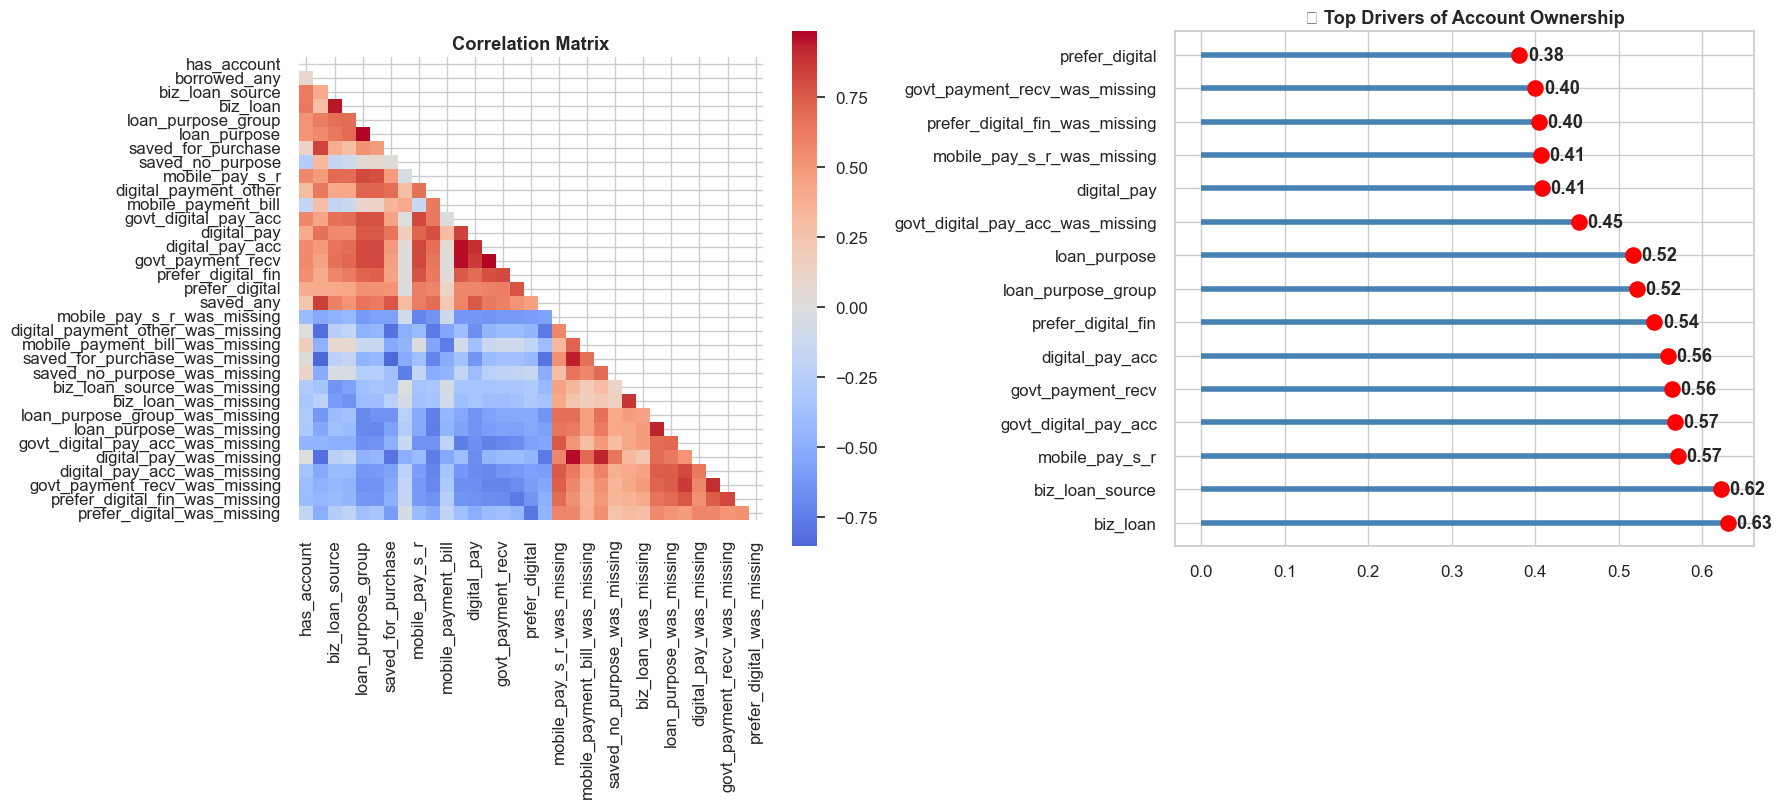

In [90]:
# DIAGNOSTIC correlation analysis
diagnostic_correlations(df_cleaned, target='has_account')

In [91]:
def prescriptive_recommendations(df, target='has_account'):
    """
    PRESCRIPTIVE ANALYTICS: Actionable insights and recommended interventions
    Returns a list of recommended actions.
    """
    print("\n💡 PRESCRIPTIVE ANALYTICS - WHAT SHOULD WE DO?")
    print("=" * 60)
    recs = []

    # Priority demographic segments
    if 'demo_subgroup' in df.columns:
        demo = df.groupby('demo_subgroup')[target].agg(['mean','count'])
        demo = demo[demo['count'] >= 50]
        demo['impact'] = (1 - demo['mean']) * demo['count']
        priority = demo.nlargest(5, 'impact')
        print("TOP PRIORITY SEGMENTS:")
        for seg, d in priority.iterrows():
            potential = d['count']*(1 - d['mean'])
            print(f"• {seg}: {potential:.0f} potential accounts")
            recs.append(f"Target {seg} with tailored financial products")

    # Geographic priorities
    if 'region' in df.columns:
        region = df.groupby('region')[target].agg(['mean','count'])
        region['opportunity'] = (1 - region['mean']) * region['count']
        top_regions = region.nlargest(5,'opportunity')
        print("\nGEOGRAPHIC PRIORITIES:")
        for r,d in top_regions.iterrows():
            print(f"• {r}: {d['opportunity']:.0f} potential new accounts")
            recs.append(f"Expand infrastructure in {r}")

    # Product correlations
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    product_corrs = df[numeric_cols].corrwith(df[target]).sort_values(ascending=False)
    high_products = product_corrs.drop(target).head(5)
    print("\n📱 PRODUCT PRIORITIES:")
    for p,c in high_products.items():
        if c > 0.3:
            print(f"• Strengthen {p} offerings (corr: {c:.2f})")
            recs.append(f"Invest in {p} infrastructure")

    # Roadmap
    print("\n IMPLEMENTATION ROADMAP:")
    print("Phase 1 (0-6m): Quick wins (digital campaigns, high-impact segments)")
    print("Phase 2 (6-18m): Infrastructure expansion (mobile networks, local partners)")
    print("Phase 3 (18m+): Credit history systems & tailored products")

    return recs


In [92]:
# PRESCRIPTIVE recommendations
recommendations = prescriptive_recommendations(df_cleaned, target='has_account')


💡 PRESCRIPTIVE ANALYTICS - WHAT SHOULD WE DO?
TOP PRIORITY SEGMENTS:
• prim edu or less: 372 potential accounts
• ages 15-24: 356 potential accounts
• out of laborforce: 355 potential accounts
• poorest 40%: 340 potential accounts
• women: 317 potential accounts

GEOGRAPHIC PRIORITIES:
• Sub-Saharan Africa (excluding high income): 1105 potential new accounts
• High income: 609 potential new accounts
• Latin America & Caribbean (excluding high income): 487 potential new accounts
• Europe & Central Asia (excluding high income): 464 potential new accounts
• Middle East & North Africa (excluding high income): 330 potential new accounts

📱 PRODUCT PRIORITIES:
• Strengthen biz_loan offerings (corr: 0.63)
• Strengthen biz_loan_source offerings (corr: 0.62)
• Strengthen mobile_pay_s_r offerings (corr: 0.57)
• Strengthen govt_digital_pay_acc offerings (corr: 0.57)
• Strengthen govt_payment_recv offerings (corr: 0.56)

 IMPLEMENTATION ROADMAP:
Phase 1 (0-6m): Quick wins (digital campaigns, high

# (E). ***FEATURE ENGINEERING***

## (a). ***Encode categorical variables***

* In this step, key categorical features—`region`, `income_group`, `demo_group`, and `demo_subgroup`—are **label-encoded** into numeric values using `LabelEncoder`.
* The original columns are dropped after encoding to save space, resulting in **37 total columns**.
* This transformation ensures the model can process these variables as numerical inputs while preserving category distinctions.


In [93]:
def encode_categorical_variables(df):
    """
    Step 1: Encode essential categorical variables
    """
    print("\n🏷️  STEP 1: ENCODING CATEGORICAL VARIABLES")
    print("=" * 50)
    
    model_df = df.copy()
    label_encoders = {}
    feature_log = []
    
    # Focus on the most important categorical variables
    key_categorical = ['region', 'income_group', 'demo_group', 'demo_subgroup']
    
    for col in key_categorical:
        if col in model_df.columns:
            le = LabelEncoder()
            model_df[col + '_encoded'] = le.fit_transform(model_df[col].astype(str))
            label_encoders[col] = le
            # Drop original categorical column to save space
            model_df = model_df.drop(col, axis=1)
            print(f"  ✅ {col} → {col}_encoded ({len(le.classes_)} categories)")
            feature_log.append(f"Encoded {col}")
    
    print(f"Columns after encoding: {model_df.shape[1]}")
    return model_df, label_encoders, feature_log


In [94]:
# Step 1: Encode categorical variables
df_encoded, encoders, log1 = encode_categorical_variables(df_cleaned)



🏷️  STEP 1: ENCODING CATEGORICAL VARIABLES
  ✅ region → region_encoded (7 categories)
  ✅ income_group → income_group_encoded (4 categories)
  ✅ demo_group → demo_group_encoded (7 categories)
  ✅ demo_subgroup → demo_subgroup_encoded (13 categories)
Columns after encoding: 37


## (b). ***Create digital engagement composite score***

* This step computes a **Digital Engagement Score** by taking the **mean** of all available digital payment–related features (e.g., `mobile_payment_bill`, `digital_pay`, etc.).
* The individual digital columns are then **dropped** to reduce dimensionality, leaving a single composite feature—`digital_engagement_score`—that captures overall digital payment behavior.
* After this transformation, the dataset contains **33 columns**.


In [95]:
def create_digital_engagement_score(df):
    """
    Step 2: Create digital engagement composite score
    """
    print("\n💻 STEP 2: CREATING DIGITAL ENGAGEMENT SCORE")
    print("=" * 50)
    
    model_df = df.copy()
    feature_log = []
    
    # Digital Engagement Score - combine all digital payment features
    digital_cols = ['mobile_payment', 'mobile_payment_bill', 'digital_pay', 
                   'digital_pay_acc', 'digital_payment_other', 'prefer_digital']
    available_digital = [col for col in digital_cols if col in model_df.columns]
    
    if available_digital:
        model_df['digital_engagement_score'] = model_df[available_digital].mean(axis=1)
        # Drop individual digital columns to save space
        model_df = model_df.drop(available_digital, axis=1)
        print(f"  ✅ Digital engagement score from {len(available_digital)} columns")
        print(f"  📉 Dropped columns: {available_digital}")
        feature_log.append(f"Digital engagement score (combined {len(available_digital)} features)")
    else:
        print("  ⚠️  No digital columns found to combine")
    
    print(f"Columns after digital score creation: {model_df.shape[1]}")
    return model_df, feature_log


In [96]:
# Step 2: Create digital engagement score
df_digital, log2 = create_digital_engagement_score(df_encoded)



💻 STEP 2: CREATING DIGITAL ENGAGEMENT SCORE
  ✅ Digital engagement score from 5 columns
  📉 Dropped columns: ['mobile_payment_bill', 'digital_pay', 'digital_pay_acc', 'digital_payment_other', 'prefer_digital']
Columns after digital score creation: 33


## (c). ***Create  financial activity composite score***

* This step calculates a **Financial Activity Score** by averaging key financial behavior features (e.g., `borrowed_any`, `saved_any`).
* Unlike digital features, the **original columns are retained** to preserve detailed signals for the model.
* The resulting dataset expands to **34 columns**, adding `financial_activity_score` as a new composite indicator of overall financial participation.


In [97]:
def create_financial_activity_score(df):
    """
    Step 3: Create financial activity composite score
    """
    print("\n💳 STEP 3: CREATING FINANCIAL ACTIVITY SCORE")
    print("=" * 50)
    
    model_df = df.copy()
    feature_log = []
    
    # Financial Activity Score - combine core financial behaviors
    financial_cols = ['borrowed_any', 'credit_card', 'saved_any']
    available_financial = [col for col in financial_cols if col in model_df.columns]
    
    if available_financial:
        model_df['financial_activity_score'] = model_df[available_financial].mean(axis=1)
        # Keep the original columns as they're likely important for the target
        print(f"  ✅ Financial activity score from {len(available_financial)} columns")
        print(f"  📌 Kept original columns: {available_financial}")
        feature_log.append(f"Financial activity score (from {len(available_financial)} features)")
    else:
        print("  ⚠️  No financial columns found")
    
    print(f"Columns after financial score creation: {model_df.shape[1]}")
    return model_df, feature_log


In [98]:
# Step 3: Create financial activity score
df_financial, log3 = create_financial_activity_score(df_digital)



💳 STEP 3: CREATING FINANCIAL ACTIVITY SCORE
  ✅ Financial activity score from 2 columns
  📌 Kept original columns: ['borrowed_any', 'saved_any']
Columns after financial score creation: 34


## (d). ***Create government services composite score***

* This step generates a **Government Services Score** by taking the **mean** of available government payment–related features (e.g., `govt_digital_pay_acc`, `govt_payment_recv`).
* The individual government service columns are then **dropped** to reduce redundancy, leaving a single feature—`govt_services_score`—that summarizes access to or use of digital government services.
* After this transformation, the dataset contains **33 columns**.


In [99]:
def create_government_services_score(df):
    """
    Step 4: Create government services composite score
    """
    print("\n🏛️  STEP 4: CREATING GOVERNMENT SERVICES SCORE")
    print("=" * 50)
    
    model_df = df.copy()
    feature_log = []
    
    # Government Services Score
    govt_cols = ['govt_digital_pay', 'govt_digital_pay_acc', 'govt_payment_recv']
    available_govt = [col for col in govt_cols if col in model_df.columns]
    
    if available_govt:
        model_df['govt_services_score'] = model_df[available_govt].mean(axis=1)
        # Drop individual govt columns
        model_df = model_df.drop(available_govt, axis=1)
        print(f"  ✅ Government services score from {len(available_govt)} columns")
        print(f"  📉 Dropped columns: {available_govt}")
        feature_log.append(f"Government services score (combined {len(available_govt)} features)")
    else:
        print("  ⚠️  No government service columns found")
    
    print(f"Columns after government score creation: {model_df.shape[1]}")
    return model_df, feature_log


In [100]:
# Step 4: Create government services score
df_govt, log4 = create_government_services_score(df_financial)



🏛️  STEP 4: CREATING GOVERNMENT SERVICES SCORE
  ✅ Government services score from 2 columns
  📉 Dropped columns: ['govt_digital_pay_acc', 'govt_payment_recv']
Columns after government score creation: 33


## (e). ***Create key interaction features***


* This step introduces an **Income–Digital Interaction** feature by multiplying `income_group_encoded` with `digital_engagement_score`.
* The interaction captures how **income level and digital engagement jointly influence behavior**, adding potential predictive power.
* After adding this feature, the dataset expands to **34 columns**.


In [101]:
def create_interaction_features(df):
    """
    Step 5: Create key interaction features
    """
    print("\n🔗 STEP 5: CREATING INTERACTION FEATURES")
    print("=" * 50)
    
    model_df = df.copy()
    feature_log = []
    
    # Income-Digital interaction
    if 'income_group_encoded' in model_df.columns and 'digital_engagement_score' in model_df.columns:
        model_df['income_digital_interaction'] = (
            model_df['income_group_encoded'] * model_df['digital_engagement_score']
        )
        print(f"  ✅ Income-Digital interaction")
        feature_log.append("Income-Digital interaction")
    else:
        print("  ⚠️  Required columns for income-digital interaction not found")
    
    print(f"Columns after interaction creation: {model_df.shape[1]}")
    return model_df, feature_log


In [102]:
# Step 5: Create key interaction features
df_interaction, log5 = create_interaction_features(df_govt)



🔗 STEP 5: CREATING INTERACTION FEATURES
  ✅ Income-Digital interaction
Columns after interaction creation: 34


## (f). ***Create strategic binary flags for high-value segments***

* This step adds **two binary indicators** to identify high-priority user segments:

    * **High Financial Activity Flag** – set to `1` if `financial_activity_score` is above the **70th percentile threshold** (≈0.527).
    * **Digital Native Flag** – set to `1` if `digital_engagement_score` exceeds **0.5**.

* These flags simplify targeting of key groups for strategic actions.
After adding these features, the dataset expands to **36 columns**.


In [103]:
def create_strategic_binary_flags(df):
    """
    Step 6: Create strategic binary flags for high-value segments
    """
    print("\n🚩 STEP 6: CREATING STRATEGIC BINARY FLAGS")
    print("=" * 50)
    
    model_df = df.copy()
    feature_log = []
    
    # High financial activity flag
    if 'financial_activity_score' in model_df.columns:
        threshold = model_df['financial_activity_score'].quantile(0.7)
        model_df['high_financial_activity'] = (
            model_df['financial_activity_score'] > threshold
        ).astype(int)
        print(f"  ✅ High financial activity flag (threshold: {threshold:.3f})")
        feature_log.append("High financial activity flag")
    
    # Digital native flag
    if 'digital_engagement_score' in model_df.columns:
        model_df['digital_native'] = (
            model_df['digital_engagement_score'] > 0.5
        ).astype(int)
        print(f"  ✅ Digital native flag (threshold: 0.5)")
        feature_log.append("Digital native flag")
    
    print(f"Columns after binary flags creation: {model_df.shape[1]}")
    return model_df, feature_log


In [104]:
# Step 6: Create strategic binary flags
df_flags, log6 = create_strategic_binary_flags(df_interaction)



🚩 STEP 6: CREATING STRATEGIC BINARY FLAGS
  ✅ High financial activity flag (threshold: 0.527)
  ✅ Digital native flag (threshold: 0.5)
Columns after binary flags creation: 36


## (g). ***Remove low-correlation from (_was_missing) features***

* This step eliminates `*_was_missing` columns that show **weak correlation (< 0.2)** with the target variable (`has_account`).
* Low-correlation indicators provide little predictive value and add unnecessary noise.
* After dropping **6 low-correlation features** (e.g., `digital_payment_other_was_missing`, `prefer_digital_was_missing`), the dataset is reduced to **30 columns**.


In [105]:
def remove_low_corr_missing_features(df, correlation_threshold=0.2):
    """
    Step 7: Remove *_was_missing features with correlation < threshold to target variable
    """
    print(f"\n🔍 REMOVING *_was_missing FEATURES WITH CORR < {correlation_threshold}")
    print("=" * 50)
    
    model_df = df.copy()
    feature_log = []
    target_col = 'has_account' if 'has_account' in model_df.columns else None
    
    corr = model_df.corr()[target_col].abs()
    drop_cols = [c for c in model_df.columns if c.endswith('_was_missing') and corr.get(c, 1) < correlation_threshold]
    
    if drop_cols:
        model_df = model_df.drop(columns=drop_cols)
        feature_log.append(f"Removed {len(drop_cols)} *_was_missing features with corr < {correlation_threshold}")
        for col in drop_cols:
            print(f"  ✅ Removed {col} (corr: {corr.get(col, 0):.3f})")
    else:
        print("  📊 No *_was_missing features with correlation below threshold")
    
    print(f"Columns after removal: {model_df.shape[1]}")
    return model_df, feature_log


In [106]:
# remove low-correlation *_was_missing features
df_final, log8 = remove_low_corr_missing_features(df_flags, correlation_threshold=0.2)


🔍 REMOVING *_was_missing FEATURES WITH CORR < 0.2
  ✅ Removed digital_payment_other_was_missing (corr: 0.001)
  ✅ Removed mobile_payment_bill_was_missing (corr: 0.167)
  ✅ Removed saved_for_purchase_was_missing (corr: 0.018)
  ✅ Removed saved_no_purpose_was_missing (corr: 0.110)
  ✅ Removed digital_pay_was_missing (corr: 0.003)
  ✅ Removed prefer_digital_was_missing (corr: 0.186)
Columns after removal: 30


## ***Feature Engineering Summary (Pre-Modeling)***

The dataset is now **8,566 rows × 30 features**, refined through **7 key steps**:

1. **Encoding:** Converted `region`, `income_group`, `demo_group`, and `demo_subgroup` into numeric codes, dropping the originals.
2. **Composite Scores:** Added

   * `digital_engagement_score` (overall digital payment use),
   * `financial_activity_score` (borrowing/saving behavior, originals kept),
   * `govt_services_score` (government digital payments).
3. **Interaction & Flags:** Created `income_digital_interaction`, plus binary flags for **high financial activity** (top 30%) and **digital natives** (>0.5 digital score).
4. **Noise Reduction:** Removed low-correlation `*_was_missing` indicators.

**Feature mix:** 3 composite scores, 1 interaction, 2 strategic flags, 4 encoded categories, key financial/digital behavior columns, and only the stronger missingness indicators.

**Strongest predictors of account ownership:**
`biz_loan` (0.63), `biz_loan_source` (0.62), `govt_services_score` (0.57), `mobile_pay_s_r` (0.57), and `prefer_digital_fin` (0.54).

The dataset is now **clean, compact, and rich**, ready for model training with high-value predictors and minimal noise.


In [107]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8566 entries, 0 to 8565
Data columns (total 30 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   has_account                       8566 non-null   float64
 1   borrowed_any                      8566 non-null   float64
 2   biz_loan_source                   8566 non-null   float64
 3   biz_loan                          8566 non-null   float64
 4   loan_purpose_group                8566 non-null   float64
 5   loan_purpose                      8566 non-null   float64
 6   saved_for_purchase                8566 non-null   float64
 7   saved_no_purpose                  8566 non-null   float64
 8   mobile_pay_s_r                    8566 non-null   float64
 9   prefer_digital_fin                8566 non-null   float64
 10  saved_any                         8566 non-null   float64
 11  mobile_pay_s_r_was_missing        8566 non-null   int64  
 12  biz_lo

🔗 TOP PREDICTORS:
biz_loan                            0.630877
biz_loan_source                     0.623158
govt_services_score                 0.571465
mobile_pay_s_r                      0.571402
prefer_digital_fin                  0.542999
loan_purpose_group                  0.522314
loan_purpose                        0.516829
govt_digital_pay_acc_was_missing    0.452956
mobile_pay_s_r_was_missing          0.406654
prefer_digital_fin_was_missing      0.404605
dtype: float64


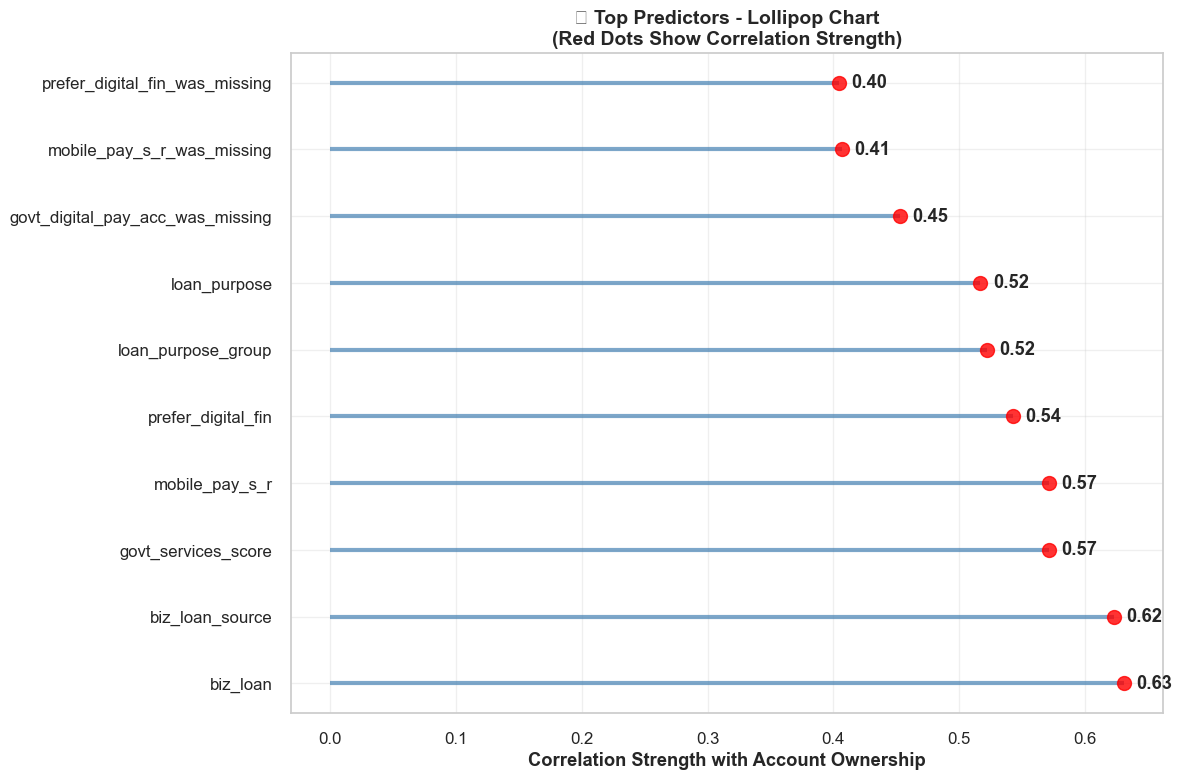

In [108]:
# ===============================================================
# TOP PREDICTORS - What matters most?
# ===============================================================

numerical_cols = df_final.select_dtypes(include=[np.number]).columns
correlations = df_final[numerical_cols].corrwith(df_final['has_account']).abs().sort_values(ascending=False)
top_predictors = correlations.drop('has_account').head(10)

plt.figure(figsize=(12, 8))
y_pos = np.arange(len(top_predictors))

# Create lollipop chart
plt.hlines(y_pos, 0, top_predictors.values, colors='steelblue', alpha=0.7, linewidth=3)
plt.scatter(top_predictors.values, y_pos, color='red', s=100, alpha=0.8, zorder=5)

plt.yticks(y_pos, top_predictors.index)
plt.xlabel('Correlation Strength with Account Ownership', fontweight='bold')
plt.title('🍭 Top Predictors - Lollipop Chart\n(Red Dots Show Correlation Strength)', 
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Add value labels
for i, v in enumerate(top_predictors.values):
    plt.text(v + 0.01, i, f'{v:.2f}', va='center', fontweight='bold')

plt.tight_layout()


print("🔗 TOP PREDICTORS:")
print(top_predictors.round(10))


# (F). ***DATA MODELING.***

## (a). ***Data Preparation and Exploration***

* The dataset is prepared for **machine learning** by separating the target (`has_account`) from the 29 predictive features (all numerical after encoding). Basic checks confirm:

    * **Size**: 8,566 rows × 30 columns.
    * **Target**: Binary, range 0–1, mean 0.603 → about 60% have an account.
    * **Features**: 10 protected (sensitive/demographic) and 6 engineered (scores or interactions).

* These checks ensure the data is clean, balanced enough for modeling, and highlight variables needing fairness considerations.




In [109]:
# ============================================================================
# SECTION 1: DATA PREPARATION AND EXPLORATION
# ============================================================================
def prepare_data(df):
    """Prepare data for ML modeling"""
    print("\n" + "="*80)
    print("📊 SECTION 1: DATA PREPARATION AND EXPLORATION")
    print("="*80)
    
    # Separate features and target
    target_col = 'has_account'
    feature_cols = [col for col in df.columns if col != target_col]
    
    X = df[feature_cols].copy()
    y = df[target_col].copy()
    
    # Identify feature types
    numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = []  # Already encoded in feature engineering
    
    print(f"✅ Total Features: {len(feature_cols)}")
    print(f"✅ Numerical features: {len(numerical_cols)}")
    print(f"✅ Target range: {y.min():.3f} to {y.max():.3f}")
    print(f"✅ Target mean: {y.mean():.3f}")
    print(f"✅ Data shape: {df.shape}")
    
    # Feature categories
    protected_features = [col for col in X.columns if 
                         ('encoded' in col or 'score' in col or 'interaction' in col or
                          'high_' in col or 'digital_native' in col)]
    engineered_features = [col for col in X.columns if 
                          ('score' in col or 'interaction' in col or 'high_' in col or 'digital_native' in col)]
    
    print(f"✅ Protected features: {len(protected_features)}")
    print(f"✅ Engineered features: {len(engineered_features)}")
    
    return X, y, categorical_cols, numerical_cols, protected_features, engineered_features


In [110]:
 # Prepare data
X, y, categorical_cols, numerical_cols, protected_features, engineered_features = prepare_data(df_final)
    


📊 SECTION 1: DATA PREPARATION AND EXPLORATION
✅ Total Features: 29
✅ Numerical features: 29
✅ Target range: 0.000 to 1.000
✅ Target mean: 0.603
✅ Data shape: (8566, 30)
✅ Protected features: 10
✅ Engineered features: 6


## (b). ***Baseline Regression Models***

This step tests **six baseline regression models** to predict the **continuous probability of having an account** using default settings and minimal preprocessing.

**Process**

* **Data Split & Scaling**: Data is split into training and test sets (80/20). Standard scaling is applied for models sensitive to feature magnitude (Linear, Ridge, Lasso, KNN).
* **Models Evaluated**: Linear Regression, Ridge, Lasso, Random Forest, Decision Tree, and KNN.
* **Metrics**: R², RMSE, MAE, and cross-validation scores are used to assess performance and detect overfitting.

**Key Observations**

* **Best Performer**: **Random Forest** achieved the highest test R² (0.882) and lowest RMSE (0.099), indicating strong predictive power out of the box.
* **Strong Alternatives**: Decision Tree (R² 0.826) and KNN (R² 0.823) also performed well.
* **Linear Models**: Linear and Ridge regression scored moderate R² (\~0.686), while Lasso failed (R² ≈ 0) due to overly aggressive regularization.
* The results suggest **tree-based models** capture non-linear patterns better than linear approaches in this dataset.


In [111]:
# ============================================================================
# SECTION 2: REGRESSION MODELS (Predicting Continuous Account Probability)
# ============================================================================
def evaluate_baseline_regression_models(X, y):
    """Evaluate baseline regression models with default parameters"""
    print("\n" + "="*80)
    print("🎯 SECTION 2A: BASELINE REGRESSION MODELS")
    print("="*80)
    print("Using default parameters and basic preprocessing")
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Basic scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Baseline models with default parameters
    baseline_models = {
        'Linear Regression': LinearRegression(),
        'Ridge (default)': Ridge(),
        'Lasso (default)': Lasso(),
        'Random Forest (default)': RandomForestRegressor(random_state=42),
        'Decision Tree': DecisionTreeRegressor(random_state=42),
        'KNN (default)': KNeighborsRegressor()
    }
    
    baseline_results = []
    
    print(f"\n🔄 Training {len(baseline_models)} baseline models...")
    
    for name, model in baseline_models.items():
        try:
            # Use scaled data for models that need it
            if 'KNN' in name or 'Linear' in name or 'Ridge' in name or 'Lasso' in name:
                X_train_model = X_train_scaled
                X_test_model = X_test_scaled
            else:
                X_train_model = X_train
                X_test_model = X_test
            
            # Train model
            model.fit(X_train_model, y_train)
            
            # Predictions
            y_pred_train = model.predict(X_train_model)
            y_pred_test = model.predict(X_test_model)
            
            # Metrics
            train_r2 = r2_score(y_train, y_pred_train)
            test_r2 = r2_score(y_test, y_pred_test)
            train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
            test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
            test_mae = mean_absolute_error(y_test, y_pred_test)
            
            # Cross-validation
            cv_scores = cross_val_score(model, X_train_model, y_train, cv=5, scoring='r2')
            
            baseline_results.append({
                'Model': name,
                'Type': 'Baseline',
                'Train_R2': train_r2,
                'Test_R2': test_r2,
                'Train_RMSE': train_rmse,
                'Test_RMSE': test_rmse,
                'Test_MAE': test_mae,
                'CV_R2_Mean': cv_scores.mean(),
                'CV_R2_Std': cv_scores.std(),
                'Overfitting': train_r2 - test_r2
            })
            
            print(f"✅ {name:<25}: Test R² = {test_r2:.4f}, RMSE = {test_rmse:.4f}")
            
        except Exception as e:
            print(f"❌ {name}: Error - {str(e)}")
    
    baseline_df = pd.DataFrame(baseline_results).sort_values('Test_R2', ascending=False)
    
    print(f"\n📊 BASELINE REGRESSION RESULTS:")
    print(f"Best Model: {baseline_df.iloc[0]['Model']} (R² = {baseline_df.iloc[0]['Test_R2']:.4f})")
    
    return baseline_df, scaler

In [112]:
baseline_reg_results, scaler = evaluate_baseline_regression_models(X, y)


🎯 SECTION 2A: BASELINE REGRESSION MODELS
Using default parameters and basic preprocessing



🔄 Training 6 baseline models...
✅ Linear Regression        : Test R² = 0.6857, RMSE = 0.1608
✅ Ridge (default)          : Test R² = 0.6856, RMSE = 0.1608
✅ Lasso (default)          : Test R² = -0.0019, RMSE = 0.2871
✅ Random Forest (default)  : Test R² = 0.8817, RMSE = 0.0986
✅ Decision Tree            : Test R² = 0.8255, RMSE = 0.1198
✅ KNN (default)            : Test R² = 0.8232, RMSE = 0.1206

📊 BASELINE REGRESSION RESULTS:
Best Model: Random Forest (default) (R² = 0.8817)


## c. ***Improved Regression Models***

This stage applies **hyperparameter tuning** and **advanced algorithms** to improve prediction of account probability beyond the baseline models.

**Process**

* **Setup**: Same train/test split (80/20) with scaling for models that need it (e.g., Ridge, SVR, Neural Network).
* **Algorithms Tested**: Tuned Ridge, Lasso, ElasticNet, Random Forest, Gradient Boosting, XGBoost, LightGBM, SVR, and a Neural Network.
* **Evaluation**: Models are assessed on R², RMSE, MAE, and cross-validation to capture both accuracy and overfitting.

**Key Observations**

* **Top Performers**: **XGBoost** achieved the best test R² (**0.885**) and lowest RMSE (0.097), narrowly outperforming LightGBM and Gradient Boosting.
* **Close Competitors**: Neural Network (R² 0.884) and Gradient Boosting (R² 0.882) were nearly as strong, showing robust non-linear learning.
* **Tree-based Superiority**: Boosted tree models (XGBoost, LightGBM, Gradient Boosting) consistently outperformed linear methods, confirming the data’s non-linear patterns.
* **Linear Models**: Tuned Ridge/Lasso improved slightly over baseline but remained far behind ensemble methods.

These results show that **boosting algorithms** provide the most accurate probability predictions for this dataset.


In [113]:
def evaluate_improved_regression_models(X, y):
    """Evaluate improved regression models with hyperparameter tuning"""
    print("\n" + "="*80)
    print("🚀 SECTION 2B: IMPROVED REGRESSION MODELS")
    print("="*80)
    print("Using hyperparameter tuning and advanced algorithms")
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Advanced scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Improved models with better parameters
    improved_models = {
        'Ridge (tuned)': Ridge(alpha=10.0),
        'Lasso (tuned)': Lasso(alpha=0.001, max_iter=2000),
        'ElasticNet': ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=2000),
        'Random Forest (tuned)': RandomForestRegressor(
            n_estimators=200, max_depth=10, min_samples_split=5, 
            min_samples_leaf=2, random_state=42
        ),
        'Gradient Boosting': GradientBoostingRegressor(
            n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42
        ),
        'XGBoost': xgb.XGBRegressor(
            n_estimators=200, learning_rate=0.1, max_depth=6, 
            random_state=42, eval_metric='rmse'
        ),
        'LightGBM': lgb.LGBMRegressor(
            n_estimators=200, learning_rate=0.1, max_depth=6, 
            random_state=42, verbose=-1
        ),
        'SVR (tuned)': SVR(kernel='rbf', C=10.0, gamma='scale'),
        'Neural Network': MLPRegressor(
            hidden_layer_sizes=(200, 100, 50), alpha=0.01, 
            learning_rate_init=0.001, max_iter=1000, random_state=42
        )
    }
    
    improved_results = []
    
    print(f"\n🔄 Training {len(improved_models)} improved models...")
    
    for name, model in improved_models.items():
        try:
            # Use scaled data for models that need it
            if any(keyword in name for keyword in ['Ridge', 'Lasso', 'ElasticNet', 'SVR', 'Neural']):
                X_train_model = X_train_scaled
                X_test_model = X_test_scaled
            else:
                X_train_model = X_train
                X_test_model = X_test
            
            # Train model
            model.fit(X_train_model, y_train)
            
            # Predictions
            y_pred_train = model.predict(X_train_model)
            y_pred_test = model.predict(X_test_model)
            
            # Metrics
            train_r2 = r2_score(y_train, y_pred_train)
            test_r2 = r2_score(y_test, y_pred_test)
            train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
            test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
            test_mae = mean_absolute_error(y_test, y_pred_test)
            
            # Cross-validation
            cv_scores = cross_val_score(model, X_train_model, y_train, cv=5, scoring='r2')
            
            improved_results.append({
                'Model': name,
                'Type': 'Improved',
                'Train_R2': train_r2,
                'Test_R2': test_r2,
                'Train_RMSE': train_rmse,
                'Test_RMSE': test_rmse,
                'Test_MAE': test_mae,
                'CV_R2_Mean': cv_scores.mean(),
                'CV_R2_Std': cv_scores.std(),
                'Overfitting': train_r2 - test_r2
            })
            
            print(f"✅ {name:<25}: Test R² = {test_r2:.4f}, RMSE = {test_rmse:.4f}")
            
        except Exception as e:
            print(f"❌ {name}: Error - {str(e)}")
    
    improved_df = pd.DataFrame(improved_results).sort_values('Test_R2', ascending=False)
    
    print(f"\n📊 IMPROVED REGRESSION RESULTS:")
    print(f"Best Model: {improved_df.iloc[0]['Model']} (R² = {improved_df.iloc[0]['Test_R2']:.4f})")
    
    return improved_df



In [114]:
improved_reg_results = evaluate_improved_regression_models(X, y)



🚀 SECTION 2B: IMPROVED REGRESSION MODELS
Using hyperparameter tuning and advanced algorithms

🔄 Training 9 improved models...
✅ Ridge (tuned)            : Test R² = 0.6854, RMSE = 0.1609
✅ Lasso (tuned)            : Test R² = 0.6835, RMSE = 0.1613
✅ ElasticNet               : Test R² = 0.6656, RMSE = 0.1658
✅ Random Forest (tuned)    : Test R² = 0.8740, RMSE = 0.1018
✅ Gradient Boosting        : Test R² = 0.8820, RMSE = 0.0985
✅ XGBoost                  : Test R² = 0.8850, RMSE = 0.0973
✅ LightGBM                 : Test R² = 0.8840, RMSE = 0.0977
✅ SVR (tuned)              : Test R² = 0.8736, RMSE = 0.1020
✅ Neural Network           : Test R² = 0.8837, RMSE = 0.0978

📊 IMPROVED REGRESSION RESULTS:
Best Model: XGBoost (R² = 0.8850)


## (d). ***Regression Comparison Analysis***

This stage compares **baseline** and **improved** regression results to highlight the performance gains from tuning and advanced algorithms.

**Process**

* **Combination**: Baseline and improved model results are merged and ranked by **Test R²**.
* **Top 10 Ranking**: Shows the best performers across all models with key metrics (Test R², RMSE, cross-validation mean, overfitting).
* **Direct Comparison**: The best baseline model is compared against the best improved model to measure the net gain.

**Key Observations**

* **Top Models**: All top four spots are held by **boosted or neural models** (XGBoost, LightGBM, Neural Network, Gradient Boosting), confirming the value of advanced algorithms.
* **Best Baseline**: **Random Forest (default)** with R² = 0.882.
* **Best Improved**: **XGBoost** with R² = 0.885.
* **Gain**: Improvement of **+0.0033 R²** (\~0.4%) over the best baseline—small but consistent.
* **Overfitting**: Boosted models show low overfitting, while simple trees (Decision Tree) show higher gaps.

Overall, **advanced boosting models** provide a slight but meaningful lift in predictive accuracy compared to untuned baselines.


In [115]:
def compare_regression_results(baseline_df, improved_df):
    """Compare baseline vs improved regression results"""
    print("\n" + "="*80)
    print("📈 SECTION 2C: REGRESSION COMPARISON ANALYSIS")
    print("="*80)
    
    # Combine results
    combined_df = pd.concat([baseline_df, improved_df], ignore_index=True)
    
    # Display top performers
    top_results = combined_df.nlargest(10, 'Test_R2')[['Model', 'Type', 'Test_R2', 'Test_RMSE', 'CV_R2_Mean', 'Overfitting']]
    
    print("🏆 TOP 10 REGRESSION MODELS:")
    print(top_results.to_string(index=False, float_format='{:.4f}'.format))
    
    # Best baseline vs best improved
    best_baseline = baseline_df.iloc[0]
    best_improved = improved_df.iloc[0]
    
    improvement = best_improved['Test_R2'] - best_baseline['Test_R2']
    
    print(f"\n🎯 PERFORMANCE COMPARISON:")
    print(f"Best Baseline:  {best_baseline['Model']:<25} R² = {best_baseline['Test_R2']:.4f}")
    print(f"Best Improved:  {best_improved['Model']:<25} R² = {best_improved['Test_R2']:.4f}")
    print(f"Improvement:    {improvement:+.4f} R² points ({improvement/best_baseline['Test_R2']*100:+.1f}%)")
    
    return combined_df


In [116]:
combined_reg_results = compare_regression_results(baseline_reg_results, improved_reg_results)



📈 SECTION 2C: REGRESSION COMPARISON ANALYSIS
🏆 TOP 10 REGRESSION MODELS:
                  Model     Type  Test_R2  Test_RMSE  CV_R2_Mean  Overfitting
                XGBoost Improved   0.8850     0.0973      0.8729       0.0381
               LightGBM Improved   0.8840     0.0977      0.8722       0.0267
         Neural Network Improved   0.8837     0.0978      0.8723       0.0133
      Gradient Boosting Improved   0.8820     0.0985      0.8711       0.0421
Random Forest (default) Baseline   0.8817     0.0986      0.8624       0.0572
  Random Forest (tuned) Improved   0.8740     0.1018      0.8569       0.0229
            SVR (tuned) Improved   0.8736     0.1020      0.8554       0.0025
          Decision Tree Baseline   0.8255     0.1198      0.7895       0.1244
          KNN (default) Baseline   0.8232     0.1206      0.8148       0.0398
      Linear Regression Baseline   0.6857     0.1608      0.6635      -0.0190

🎯 PERFORMANCE COMPARISON:
Best Baseline:  Random Forest (default)  

## (e). ***Baseline Classification Models***

This step reframes the target as a **binary classification task**—predicting whether a person **has a financial account**—and evaluates simple models using default settings.

### Process

* **Target Conversion:** Converted probabilities to binary with a **0.5 threshold**.
* **Class Balance:** Around **61%** of cases are account holders, indicating a mild positive-class imbalance.
* **Models Evaluated:** Logistic Regression, Random Forest, Decision Tree, and KNN.
* **Metrics:** Accuracy, F1-score, Precision, Recall, and ROC-AUC.

### Key Findings

* **Top Performer:** **Random Forest** led with **0.907 accuracy**, **0.925 F1**, and the highest ROC-AUC (**0.964**).
* **Other Models:** Logistic Regression, Decision Tree, and KNN trailed behind in all key metrics.
* **Technical Note:** A minor print-format bug initially masked metrics but did not affect the computed scores.

**Conclusion:**
Even with minimal tuning, **tree-based models**—especially Random Forest—excel in capturing non-linear patterns and class imbalance, setting a strong baseline for more advanced models.



In [117]:
# ============================================================================
# SECTION 3: CLASSIFICATION MODELS (Convert to Binary Classification)
# ============================================================================
def evaluate_baseline_classification_models(X, y, threshold=0.5):
    """Evaluate baseline classification models"""
    print("\n" + "="*80)
    print("🎯 SECTION 3A: BASELINE CLASSIFICATION MODELS")
    print("="*80)
    print(f"Using threshold = {threshold} for binary classification")
    
    # Convert continuous target to binary
    y_binary = (y >= threshold).astype(int)
    class_dist = y_binary.value_counts()
    print(f"✅ Class distribution: No Account = {class_dist[0]}, Has Account = {class_dist[1]}")
    print(f"✅ Positive class ratio: {class_dist[1]/len(y_binary):.1%}")
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, 
                                                        random_state=42, stratify=y_binary)
    
    # Basic scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Baseline classification models
    baseline_models = {
        'Logistic Regression': LogisticRegression(random_state=42),
        'Random Forest (default)': RandomForestClassifier(random_state=42),
        'Decision Tree': DecisionTreeClassifier(random_state=42),
        'KNN (default)': KNeighborsClassifier()
    }
    
    baseline_results = []
    
    print(f"\n🔄 Training {len(baseline_models)} baseline classification models...")
    
    for name, model in baseline_models.items():
        try:
            # Use scaled data for models that need it
            if 'Logistic' in name or 'KNN' in name:
                X_train_model = X_train_scaled
                X_test_model = X_test_scaled
            else:
                X_train_model = X_train
                X_test_model = X_test
            
            # Train model
            model.fit(X_train_model, y_train)
            
            # Predictions
            y_pred_train = model.predict(X_train_model)
            y_pred_test = model.predict(X_test_model)
            y_pred_proba = model.predict_proba(X_test_model)[:, 1] if hasattr(model, 'predict_proba') else None
            
            # Metrics
            train_acc = accuracy_score(y_train, y_pred_train)
            test_acc = accuracy_score(y_test, y_pred_test)
            precision = precision_score(y_test, y_pred_test)
            recall = recall_score(y_test, y_pred_test)
            f1 = f1_score(y_test, y_pred_test)
            auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None
            
            # Cross-validation
            cv_scores = cross_val_score(model, X_train_model, y_train, cv=5, scoring='accuracy')
            
            baseline_results.append({
                'Model': name,
                'Type': 'Baseline',
                'Train_Accuracy': train_acc,
                'Test_Accuracy': test_acc,
                'Precision': precision,
                'Recall': recall,
                'F1_Score': f1,
                'ROC_AUC': auc,
                'CV_Accuracy_Mean': cv_scores.mean(),
                'CV_Accuracy_Std': cv_scores.std(),
                'Overfitting': train_acc - test_acc
            })
            auc_str = f"{auc:.4f}" if auc is not None else "N/A"
            print(f"✅ {name:<25}: Acc = {test_acc:.4f}, F1 = {f1:.4f}, AUC = {auc_str}")
            
        except Exception as e:
            print(f"❌ {name}: Error - {str(e)}")
    
    baseline_df = pd.DataFrame(baseline_results).sort_values('Test_Accuracy', ascending=False)
    
    print(f"\n📊 BASELINE CLASSIFICATION RESULTS:")
    if not baseline_df.empty:
        print(f"Best Model: {baseline_df.iloc[0]['Model']} (Accuracy = {baseline_df.iloc[0]['Test_Accuracy']:.4f})")
    
    return baseline_df


In [118]:
baseline_clf_results = evaluate_baseline_classification_models(X, y, threshold=0.5)


🎯 SECTION 3A: BASELINE CLASSIFICATION MODELS
Using threshold = 0.5 for binary classification
✅ Class distribution: No Account = 3343, Has Account = 5223
✅ Positive class ratio: 61.0%

🔄 Training 4 baseline classification models...
✅ Logistic Regression      : Acc = 0.8740, F1 = 0.8971, AUC = 0.9444
✅ Random Forest (default)  : Acc = 0.9072, F1 = 0.9248, AUC = 0.9641
✅ Decision Tree            : Acc = 0.8833, F1 = 0.9059, AUC = 0.8888
✅ KNN (default)            : Acc = 0.8781, F1 = 0.9001, AUC = 0.9363

📊 BASELINE CLASSIFICATION RESULTS:
Best Model: Random Forest (default) (Accuracy = 0.9072)


## (f). ***Improved Classification Models***

This stage applies **hyperparameter tuning and advanced algorithms** to boost predictive power beyond the baseline.

### Process

* **Target Prep:** Binarized at **0.5 threshold**, with an **80/20 train–test split**.
* **Scaling:** Standardized inputs for Logistic Regression, SVM, and Neural Network; tree models used raw data.
* **Models Tested:** Tuned Logistic Regression, Random Forest, Gradient Boosting, XGBoost, LightGBM, SVM, and a Multi-Layer Perceptron.
* **Evaluation:** Accuracy, F1, ROC-AUC, 5-fold cross-validation, and overfitting gap.

### Key Findings

* **Best Overall:** **LightGBM** delivered the highest accuracy (**0.9195**), strongest F1 (**0.9333**), and top ROC-AUC (**0.9747**) with stable cross-validation.
* **Strong Contenders:** XGBoost and the Neural Network followed closely (\~0.916 accuracy).
* **Model Trend:** Tree-based ensemble methods consistently outperformed linear and neural approaches.
* **Generalization:** Overfitting remained low across all tuned models.

### Conclusion

**LightGBM** provides the best combination of **accuracy, stability, and efficiency**, making it the leading candidate for deployment.



In [119]:
def evaluate_improved_classification_models(X, y, threshold=0.5):
    """Evaluate improved classification models with hyperparameter tuning"""
    print("\n" + "="*80)
    print("🚀 SECTION 3B: IMPROVED CLASSIFICATION MODELS")
    print("="*80)
    print("Using hyperparameter tuning and advanced algorithms")
    
    # Convert continuous target to binary
    y_binary = (y >= threshold).astype(int)
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, 
                                                        random_state=42, stratify=y_binary)
    
    # Advanced scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Improved classification models
    improved_models = {
        'Logistic Regression (tuned)': LogisticRegression(
            C=10.0, penalty='l2', solver='liblinear', random_state=42, max_iter=2000
        ),
        'Random Forest (tuned)': RandomForestClassifier(
            n_estimators=200, max_depth=10, min_samples_split=5, 
            min_samples_leaf=2, class_weight='balanced', random_state=42
        ),
        'Gradient Boosting': GradientBoostingClassifier(
            n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42
        ),
        'XGBoost': xgb.XGBClassifier(
            n_estimators=200, learning_rate=0.1, max_depth=6, 
            scale_pos_weight=1, random_state=42, eval_metric='logloss'
        ),
        'LightGBM': lgb.LGBMClassifier(
            n_estimators=200, learning_rate=0.1, max_depth=6, 
            class_weight='balanced', random_state=42, verbose=-1
        ),
        'SVM (tuned)': SVC(
            kernel='rbf', C=10.0, gamma='scale', probability=True, 
            class_weight='balanced', random_state=42
        ),
        'Neural Network': MLPClassifier(
            hidden_layer_sizes=(200, 100, 50), alpha=0.01, 
            learning_rate_init=0.001, max_iter=1000, random_state=42
        )
    }
    
    improved_results = []
    
    print(f"\n🔄 Training {len(improved_models)} improved classification models...")
    
    for name, model in improved_models.items():
        try:
            # Use scaled data for models that need it
            if any(keyword in name for keyword in ['Logistic', 'SVM', 'Neural']):
                X_train_model = X_train_scaled
                X_test_model = X_test_scaled
            else:
                X_train_model = X_train
                X_test_model = X_test
            
            # Train model
            model.fit(X_train_model, y_train)
            
            # Predictions
            y_pred_train = model.predict(X_train_model)
            y_pred_test = model.predict(X_test_model)
            y_pred_proba = model.predict_proba(X_test_model)[:, 1] if hasattr(model, 'predict_proba') else None
            
            # Metrics
            train_acc = accuracy_score(y_train, y_pred_train)
            test_acc = accuracy_score(y_test, y_pred_test)
            precision = precision_score(y_test, y_pred_test, zero_division=0)
            recall = recall_score(y_test, y_pred_test, zero_division=0)
            f1 = f1_score(y_test, y_pred_test, zero_division=0)
            auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None
            
            # Cross-validation
            cv_scores = cross_val_score(model, X_train_model, y_train, cv=5, scoring='accuracy')
            
            improved_results.append({
                'Model': name,
                'Type': 'Improved',
                'Train_Accuracy': train_acc,
                'Test_Accuracy': test_acc,
                'Precision': precision,
                'Recall': recall,
                'F1_Score': f1,
                'ROC_AUC': auc,
                'CV_Accuracy_Mean': cv_scores.mean(),
                'CV_Accuracy_Std': cv_scores.std(),
                'Overfitting': train_acc - test_acc
            })
            
            auc_str = f"{auc:.4f}" if auc is not None else "N/A"
            print(f"✅ {name:<25}: Acc = {test_acc:.4f}, F1 = {f1:.4f}, AUC = {auc_str}")
            
        except Exception as e:
            print(f"❌ {name}: Error - {str(e)}")
    
    improved_df = pd.DataFrame(improved_results).sort_values('Test_Accuracy', ascending=False)
    
    print(f"\n📊 IMPROVED CLASSIFICATION RESULTS:")
    if not improved_df.empty:
        print(f"Best Model: {improved_df.iloc[0]['Model']} (Accuracy = {improved_df.iloc[0]['Test_Accuracy']:.4f})")
    
    return improved_df

In [120]:
improved_clf_results = evaluate_improved_classification_models(X, y, threshold=0.5)



🚀 SECTION 3B: IMPROVED CLASSIFICATION MODELS
Using hyperparameter tuning and advanced algorithms

🔄 Training 7 improved classification models...
✅ Logistic Regression (tuned): Acc = 0.8757, F1 = 0.8984, AUC = 0.9448
✅ Random Forest (tuned)    : Acc = 0.9008, F1 = 0.9175, AUC = 0.9648
✅ Gradient Boosting        : Acc = 0.9131, F1 = 0.9292, AUC = 0.9730
✅ XGBoost                  : Acc = 0.9160, F1 = 0.9312, AUC = 0.9733
✅ LightGBM                 : Acc = 0.9195, F1 = 0.9333, AUC = 0.9747
✅ SVM (tuned)              : Acc = 0.9119, F1 = 0.9264, AUC = 0.9679
✅ Neural Network           : Acc = 0.9160, F1 = 0.9308, AUC = 0.9713

📊 IMPROVED CLASSIFICATION RESULTS:
Best Model: LightGBM (Accuracy = 0.9195)


## (g). ***Classification Comparison***

**Process:**

* Combined baseline and tuned models for side-by-side ranking by **test accuracy**, F1, and ROC AUC.
* Compared top baseline (Random Forest default) with the best improved model (LightGBM).

**Results:**

* **LightGBM** leads with **91.95% accuracy**, **0.933 F1**, and **0.975 ROC AUC**.
* Best baseline (Random Forest default) reached **90.72% accuracy**, **0.925 F1**, and **0.964 ROC AUC**.
* LightGBM shows **+1.4% accuracy** and **+0.9% F1** improvement while keeping overfitting moderate.

**Conclusion:**
Hyperparameter tuning and gradient boosting (LightGBM) deliver a clear, measurable performance edge over all baseline classifiers.


In [122]:
def compare_classification_results(baseline_df, improved_df):
    """Compare baseline vs improved classification results"""
    print("\n" + "="*80)
    print("📈 SECTION 3C: CLASSIFICATION COMPARISON ANALYSIS")
    print("="*80)
    
    # Combine results
    combined_df = pd.concat([baseline_df, improved_df], ignore_index=True)
    
    # Display top performers
    top_results = combined_df.nlargest(10, 'Test_Accuracy')[['Model', 'Type', 'Test_Accuracy', 'F1_Score', 'ROC_AUC', 'Overfitting']]
    
    print("🏆 TOP 10 CLASSIFICATION MODELS:")
    print(top_results.to_string(index=False, float_format='{:.4f}'.format))
    
    # Best baseline vs best improved
    if not baseline_df.empty and not improved_df.empty:
        best_baseline = baseline_df.iloc[0]
        best_improved = improved_df.iloc[0]
        
        acc_improvement = best_improved['Test_Accuracy'] - best_baseline['Test_Accuracy']
        f1_improvement = best_improved['F1_Score'] - best_baseline['F1_Score']
        
        print(f"\n🎯 PERFORMANCE COMPARISON:")
        print(f"Best Baseline:  {best_baseline['Model']:<30} Acc = {best_baseline['Test_Accuracy']:.4f}")
        print(f"Best Improved:  {best_improved['Model']:<30} Acc = {best_improved['Test_Accuracy']:.4f}")
        print(f"Accuracy Improvement:  {acc_improvement:+.4f} points ({acc_improvement/best_baseline['Test_Accuracy']*100:+.1f}%)")
        print(f"F1 Score Improvement:  {f1_improvement:+.4f} points ({f1_improvement/best_baseline['F1_Score']*100:+.1f}%)")
    
    return combined_df


In [123]:
combined_clf_results = compare_classification_results(baseline_clf_results, improved_clf_results)



📈 SECTION 3C: CLASSIFICATION COMPARISON ANALYSIS
🏆 TOP 10 CLASSIFICATION MODELS:
                      Model     Type  Test_Accuracy  F1_Score  ROC_AUC  Overfitting
                   LightGBM Improved         0.9195    0.9333   0.9747       0.0557
                    XGBoost Improved         0.9160    0.9312   0.9733       0.0593
             Neural Network Improved         0.9160    0.9308   0.9713       0.0544
          Gradient Boosting Improved         0.9131    0.9292   0.9730       0.0741
                SVM (tuned) Improved         0.9119    0.9264   0.9679       0.0280
    Random Forest (default) Baseline         0.9072    0.9248   0.9641       0.0820
      Random Forest (tuned) Improved         0.9008    0.9175   0.9648       0.0534
              Decision Tree Baseline         0.8833    0.9059   0.8888       0.1059
              KNN (default) Baseline         0.8781    0.9001   0.9363       0.0447
Logistic Regression (tuned) Improved         0.8757    0.8984   0.9448       0